<img src="https://dootoo.app/images/thoughtswork_banner.png"/>

# Kaggle Competition Submission: Titanic Passenger Survival Classification

* **Author:** Paul Tongyoo
* **Contact:** Message me on <a href="https://www.linkedin.com/in/paultongyoo/">LinkedIn</a>
* **Date:** June 29, 2025
* **Official Competition Page:** <a href="https://www.kaggle.com/competitions/titanic">Titanic: Machine Learning from Disaster</a>
* **Kaggle Submission Accuracy:** 0.76794

## Table of Contents

1. [Project Summary](#Project-Summary)
    1. [What I Did](#What-I-Did)
    1. [What I Learned](#What-I-Learned)
    1. [Next Steps](#Next-Steps)
1. [Problem Context](#Problem-Context)
1. [Source Data](#Source-Data)
    1. [Data Dictionary](#Data-Dictionary)
    1. [Variable Notes](#Variable-Notes)
1. [Model Development Strategy](#Model-Development-Strategy)
    1. [Data Sets](#Data-Sets)
    1. [Five Stage Process](#Five-Stage-Process)
    1. [Metrics Strategy](#Metrics-Strategy)
1. [Implementation](#Implementation)
    1. [Descriptive Statistics](#Descriptive-Statistics)
    1. [Data Types](#Data-Types)
    1. [Missing Values Summary](#Missing-Values-Summary)
    1. [Visual Inspection Insights](#Visual-Inspection-Insights)
    1. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
        1. [Survived (Target)](#Survived-Target)
        1. [Age](#Age)
        1. [Fare](#Fare)
        1. [Deck](#Deck)
        1. [Family Size](#Family-Size)
        1. [Sex x Is_Alone](#Sex-x-Is_Alone)
    1. [Feature Engineering](#Feature-Engineering)
        1. [Feature Creation](#Feature-Creation)
        1. [Pipeline Imputers](#Pipeline-Imputers)
    1. [Model Development](#Model-Development)
        1. [Stage 1: Bias Optimization](#Stage-1-Bias-Optimization)
        1. [Training Set Prediction Mistake Analysis](#Training-Set-Prediction-Mistake-Analysis)
            1. [Correct vs Mistake Feature Distribution Comparison](#Correct-vs-Mistake-Feature-Distribution-Comparison)
            1. [Feature Predictiveness of High-Confidence Mistakes](#Feature-Predictiveness-of-High-Confidence-Mistakes)
            1. [Model Mis-Predictions EDA](#Model-Mis-Predictions-EDA)
        1. [Stage 2: Generalization Optimization](#Stage-2-Generalization-Optimization)
        1. [Stage 3: Final Generalization Evaluation](#Stage-3-Final-Generalization-Evaluation)
        1. [Stages 1-3 Evaluation Summary](#Stages-1-3-Evaluation-Summary)
    1. [Submission File Generation](#Submission-File-Generation)

## Project Summary

In [1]:
# TODO Complete after project is finished

### What I Did

In [2]:
# TODO

### What I Learned

In [3]:
# TODO

### Next Steps

In [4]:
# TODO

## Problem Context

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, Kaggle asked us to build a predictive model that answers the question: **“What sorts of people were more likely to survive?”** using passenger data (e.g. name, age, gender, socio-economic class, etc).

## Source Data

Kaggle provided passenger data split into two files:
* "Training Set" (<a href="./input/train.csv">train.csv</a>)
    * 891 rows, 12 features
* "Test Set" (<a href="./input/test.csv">test.csv</a>)
    * 418 rows, 11 features (no `Survived` col)

### Data Dictionary

| Variable | Definition | Key, Example |
| -------- | ---------- | --- |
| **Survived** (target) | Survival | 0 = No, 1 = Yes |
| **PassengerId** | Integer index of passenger | 0,1,2,3,... |
| **Name** | Name of passenger including title | Braund, Mr. Owen Harris |
| **Pclass** | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| **Sex** | Sex | female, male |
| **Age** | Age in years | 0.15, 2, 15 |
| **SibSp** | # of siblings / spouses aboard the Titanic | 0,1,2,3,.. |
| **Parch** | # of parents / children aboard the Titanic | 0,1,2,3,.. |
| **Ticket** | Ticket number, some with prefixes, **shared among groups** | SW/PP 751 |
| **Fare** | Passenger fare, **shared among groups**	 | 7.91, 14.4542, 512.3292 |
| **Cabin** | Cabin number(s) listed on ticket, prefixed with deck letter, **shared among groups**	 | A20, "B57 B59 B63 B66"	 |
| **Embarked** | Port of Embarkation | C = Cherbourg (France), Q = Queenstown (Ireland), S = Southampton (England) |

### Variable Notes

**pclass:** A proxy for socio-economic status (SES)
* 1st = Upper
* 2nd = Middle
* 3rd = Lower

**age:** Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

**sibsp:** The dataset defines family relations in this way...
* Sibling = brother, sister, stepbrother, stepsister
* Spouse = husband, wife (mistresses and fiancés were ignored)

**parch:** The dataset defines family relations in this way...
* Parent = mother, father
* Child = daughter, son, stepdaughter, stepson
* Some children travelled only with a nanny, therefore parch=0 for them.

## Model Development Strategy

### Data Sets


The Training Set will be split into two data sets:
* `X_train, y_train` (80%)
* `X_dev, y_dev` (20%)

The Test Set will be maintained as a single data set:
* `X_test` (100%)


### Five Stage Process


Model development follows a five-stage process to optimize bias, variance, and generalization to the test set:
* **Stage 1: Bias Optimization**
    * Uses only `X_train, y_train`.
    * Used to evaluate model bias only (not variance) using `model.predict(X_train)`.
    * Diagnostic fits done at this stage to identify high-bias model types and features to avoid and/or optimize in Stage 2.
* **Stage 2: Generalization Optimization**: 
    * Uses only `X_train, y_train`.
    * Cross-validation performed to assess model generalization performance across CV loops
        * Provides some bias/variance insights by comparing performance across loops.
        * Final variance checks against single holdout distribution will be possible in Stage 3.
    * Final model selection, feature engineering, and hyperparameter tuning done in this stage.
    * CV stratification will be limited to label-based stratification only to start.
        * If the model generalizes poorly to `X_test` compared to `X_dev` (e.g., error gap > 2 pp), Stage 5: Distribution Alignment will be triggered to investigate covariate shift.
* **Stage 3: Final Generalization Evaluation**
    * Uses only `X_dev, y_dev`.
    * Model evaluated using truly unseen data.
    * Used to evaluate model variance by comparing scores with scores obtained during Stage 2.
    * If model variance exceeds `2 pp`, return to Stage 2 or 1 to iterate on model hyperparameters, features, and/or model type.
* **Stage 4: Submission Evaluation**
    * `X_train, y_train` and `X_dev, y_dev` sets will be combined into `X_train_full, y_train_full`.
    * Model will be retrained on `X_train_full`.
    * Model is then used to predict labels on `X_test`.
    * Labeled `X_test` is submitted to Kaggle's site for accuracy scoring.
    * If generalization error between `X_train_full` and `X_test` is exceeds `2 pp` than `X_train_full`/`X_dev` generalization error, proceed to Stage 5.
* **(Future) Stage 5: Train/Test Set Distribution Alignment**
    * A **discriminator classifier** will be trained and evaluated to learn if the classifier is able to distinguish between the processed `X_train_full` and `X_test` rows (`P(Row is a X_test row = 1)`).
        * If `ROC AUC ≤ 0.52`:
            * The sets are likely distributionally identical.
            * No sample reweighting will be applied and further investigation will be conducted.
        * If `ROC AUC > 0.52`:
            * The sets differ.
            * Sample reweighting will increase the weight of training samples resembling test set rows.
            * Repeat Stage 4 with new sample weights and compare new generalization scores.

Evaluation metrics (Log Loss, PR AUC, etc.) are detailed in the [Metrics Strategy](#metrics-strategy) section and used consistently across all stages.

### Metrics Strategy

* Due to imbalanced survival rate (vast majority perished), metrics that measure accurate prediction of the minority positive class will be prioritized.
* The following metrics will be used to evaluate each stage of model development, in priority order:
    * Log loss
    * PR AUC
    * F1 score
        * Precision
        * Recall
    * Accuracy



## Implementation

In [5]:
from datetime import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import chi2_contingency, ks_2samp

import mlflow
from mlflow.models.signature import infer_signature
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*Inferred schema contains integer column.*",
    module="mlflow\\.types\\.utils"
)

from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate, learning_curve, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, log_loss, make_scorer, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

from sklearn.linear_model import LogisticRegression
import optuna

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, StandardScaler, OneHotEncoder, KBinsDiscretizer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
import shap



In [6]:
training_set_df = pd.read_csv('./input/train.csv')
target = 'Survived'

# Training Set (with labels)
X_train = training_set_df.drop(columns=target)
y_train = training_set_df[target]

# Kaggle Titanic Submission Test Set (no labels)
X_test = pd.read_csv('./input/test.csv')

# Split the training set into Training and "Dev" (aka "Validation" aka "Holdout") sets
# Training Set is split using label stratification only for now to balance target classes across sets.
# Additional stratification will be explored later if unable to address generalization issues with the current split.
X_train, X_dev, y_train, y_dev = train_test_split(X_train, y_train, stratify=y_train, test_size=0.2, random_state=42)

X_train.shape, y_train.shape, X_dev.shape, y_dev.shape, X_test.shape

((712, 11), (712,), (179, 11), (179,), (418, 11))

### Descriptive Statistics

In [7]:
pd.concat([X_train, y_train], axis=1).describe(include='all')

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
count,712.000000,712.000000,712,712,575.000000,712.000000,712.000000,712,712.000000,160,710,712.000000
unique,NaN,NaN,712,2,NaN,NaN,NaN,571,NaN,127,3,NaN
top,NaN,NaN,"Lam, Mr. Ali",male,NaN,NaN,NaN,1601,NaN,G6,S,NaN
freq,NaN,NaN,1,459,NaN,NaN,NaN,6,NaN,4,516,NaN
mean,444.405899,2.308989,NaN,NaN,29.807687,0.492978,0.390449,NaN,31.819826,NaN,NaN,0.383427
std,257.465527,0.833563,NaN,NaN,14.485211,1.060720,0.838134,NaN,48.059104,NaN,NaN,0.486563
min,1.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN,0.000000
25%,222.750000,2.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN,0.000000
50%,439.500000,3.000000,NaN,NaN,28.500000,0.000000,0.000000,NaN,14.454200,NaN,NaN,0.000000
75%,667.250000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN,1.000000


Initial numerical insights:
* **PassengerId:** Column is most likely a sequential integer index from 1 to 891
* **Survived:** Mean survival rate for this data set is 38.3%, imbalance warrants focus on precision/recall of minority positive class
* **Pclass:** Top 25% of passengers were in 1st and 2nd Class, majority 75% in 3rd class
* **Age:** Youngest child was less than 6 months old, oldest is 80 years old.  Median age 28.5 yrs, 75th pecentile 39 yrs.  Contains missing values.
* **SibSp / Parch**:  At least 50% of passengers traveled alone, 75% passengers had at most 1 sibling or spouse.  Max family size is 8
* **Fare:** Fares ranged from 0.00 (potentially crew?) to 512.32.  Median fare 14.45, 75th percentile 31.00 - highest fares likely correlates with upper class

Initial categorical insights:
* **Name:** Contains surname and title info, probable tokens for splitting
* **Sex:** Majority of passengers were male
* **Ticket:** Contains number; some contain prefixes with potentially useful info. 140+ passengers shared the same ticket number, indicating traveling together (may be family and/or household staff)
* **Cabin:** Contains room number and deck letter prefix.  Some cabin strings contain multiple cabin numbers, may also signal family or household staff relationships.  687 values missing
* **Embarked:** Majority of passengers embarked from Southampton, England (644).  2 values missing

### Data Types

In [8]:
pd.concat([X_train, y_train], axis=1).dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
Survived         int64
dtype: object

### Missing Values Summary

Missing values to impute across Training and Test Sets:
* Training Set
    * `Age`
    * `Cabin`
    * `Embarked`
* Test Set
    * `Age`
    * `Cabin`
    * `Fare`

In [9]:
print(X_train.isnull().sum().loc[lambda x: x > 0])
print()
print(X_test.isnull().sum().loc[lambda x: x > 0])

Age         137
Cabin       552
Embarked      2
dtype: int64

Age       86
Fare       1
Cabin    327
dtype: int64


### Visual Inspection Insights

* Visual inspection shows variations in **ticket prefixes**, **cabin numbers (e.g. multiple numbers)** and **name tokens (e.g. title, multiple names)**.
* `Fare` is identical amongst passengers with same `Ticket`, suggesting **`Fare` might be shared amongst shared ticket holders.**
* `Name` occassionally contains another name in parenthesis (e.g. `Taussig, Mrs. Emil (Tillie Mandelbaum)`)
* `Ticket` prefixes need cleaning and consolidation (e.g. `W./C.` and `W/C` likely the same)

In [10]:
X_train.sort_values(by="Ticket")

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
257,258,1,"Cherry, Miss. Gladys",female,30.0,0,0,110152,86.500,B77,S
585,586,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.650,E68,S
262,263,1,"Taussig, Mr. Emil",male,52.0,1,1,110413,79.650,E67,S
558,559,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.650,E67,S
475,476,1,"Clifford, Mr. George Quincy",male,NaN,0,0,110465,52.000,A14,S
...,...,...,...,...,...,...,...,...,...,...,...
736,737,3,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0,1,3,W./C. 6608,34.375,NaN,S
147,148,3,"Ford, Miss. Robina Maggie ""Ruby""",female,9.0,2,2,W./C. 6608,34.375,NaN,S
235,236,3,"Harknett, Miss. Alice Phoebe",female,NaN,0,0,W./C. 6609,7.550,NaN,S
219,220,2,"Harris, Mr. Walter",male,30.0,0,0,W/C 14208,10.500,NaN,S


### Exploratory Data Analysis

In [11]:
def numeric_features(X_df, features):
    """
    Returns a list of numeric features from the DataFrame.
    
    Parameters:
    - X_df: DataFrame containing the features
    - features: List of feature names to check
    
    Returns:
    - List of numeric feature names
    """
    return [feature for feature in features if pd.api.types.is_numeric_dtype(X_df[feature])]

In [12]:
def visualize_feature(X_df, feature, y_df=None):
    if y_df is not None:
        df = pd.concat([X_df[feature], y_df], axis=1)
        df.columns = [feature, 'Survived']
    else:
        df = X_df
    plt.figure(figsize=(5, 3))
    if pd.api.types.is_numeric_dtype(X_df[feature]):
        if y_df is not None:
            sns.displot(x=feature, hue='Survived', data=df, bins=30, kde=True)
        else:
            sns.histplot(x=feature, data=df, bins=30, kde=True)
        plt.xlabel(feature)
        plt.title(f'Histogram of {feature} by Survived')
        plt.show()
    else:
        if y_df is not None:
            sns.countplot(x=feature, hue='Survived', data=df)
        else:
            sns.countplot(x=feature, data=df)
        plt.title(f'Countplot of {feature} by Survived')
        plt.show()

#### Survived (Target)

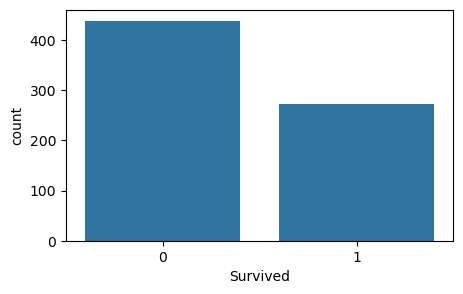

Global Survival Rate: 0.3834
Baseline Accuracy (if predicting majority class): 0.6166


In [13]:
y_df = pd.DataFrame(y_train).reset_index(drop=True)

plt.figure(figsize=(5, 3))
sns.countplot(x='Survived', data=y_df)
plt.show()

global_survival_rate = y_df['Survived'].mean()
print(f"Global Survival Rate: {global_survival_rate:.4f}")
print(f"Baseline Accuracy (if predicting majority class): {max(global_survival_rate, 1 - global_survival_rate):.4f}") 

#### Age

Derived domain-binned 'Age_Bin' feature based on non-linear age-survival relationship.
* Child: 0-10 years
* Teen: 10-17 years
* Young Adult: 17-35 years
* Middle Aged: 35-55 years
* Senior: 55-100 years

<Figure size 500x300 with 0 Axes>

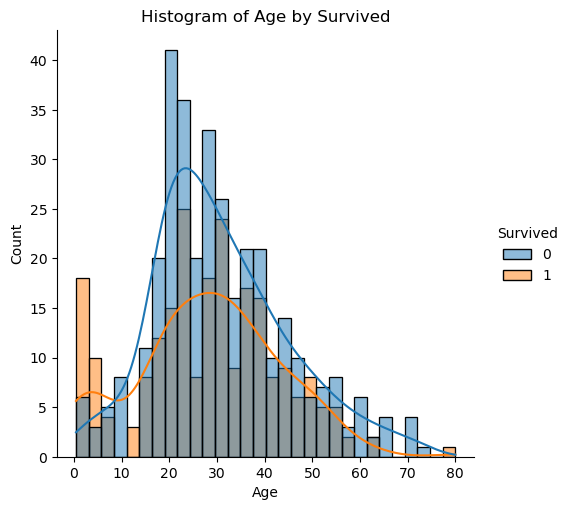

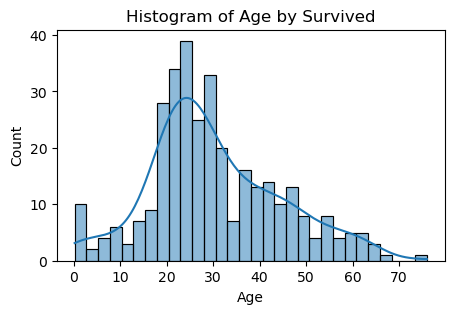

In [14]:
visualize_feature(X_train, 'Age', y_train)
visualize_feature(X_test, 'Age')

#### Fare

<Figure size 500x300 with 0 Axes>

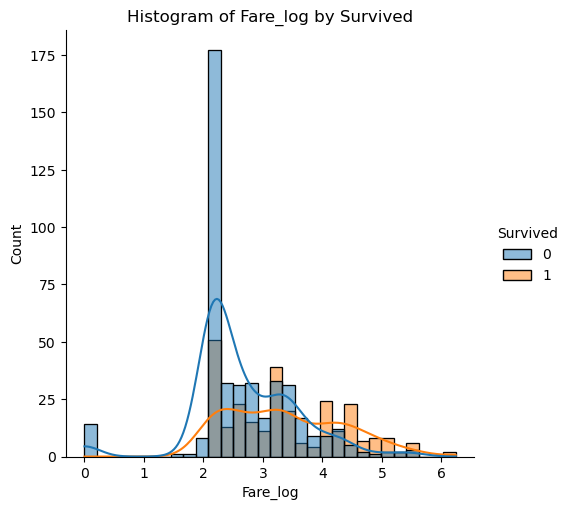

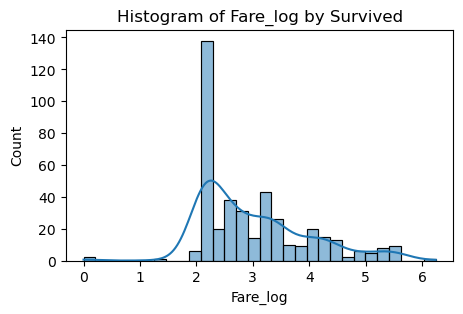

In [15]:
# Make copy of X_train/X_test and take Log1p of Fare to reduce skewness
# Make copy of only Fare column to avoid modifying original DataFrame
X_train_fare = X_train[['Fare']].copy()
X_train_fare['Fare_log'] = np.log1p(X_train_fare)

X_test_fare = X_test[['Fare']].copy()
X_test_fare['Fare_log'] = np.log1p(X_test_fare)

visualize_feature(X_train_fare, 'Fare_log', y_train)
visualize_feature(X_test_fare, 'Fare_log')  

# Ensure this feature is not used in model training directly to prevent data leakage
# log(Fare) must be done within pipeline to constrain calculation to training set only

#### Deck

* Sparse individual deck counts warrant binning to increase potential signal
* Analysis of class distribution across decks yielded the following groups:
    * `ABC`: 1st class only
    * `DE`: 1st class and some 2nd class
    * `Rare` : Lower and rarely occupied decks
    * `Unknown` : Deck letter unassigned

In [16]:
X_train_deck = X_train[['Cabin', 'Pclass']].copy()
X_train_deck['Deck'] = X_train_deck['Cabin'].str[0].fillna('Unknown')
comb_df = pd.concat([X_train_deck, y_train], axis=1)
survival_df = (
    comb_df
    .groupby("Deck", observed=True)
    .agg(
        Survival_Rate=('Survived', 'mean'),
        Count=('Survived', 'size'),
        Pclass_1_Count=('Pclass', lambda x: (x == 1).sum()),
        Pclass_2_Count=('Pclass', lambda x: (x == 2).sum()),
        Pclass_3_Count=('Pclass', lambda x: (x == 3).sum())
    )
    .reset_index()
    .sort_values(by="Deck", ascending=True)
)
survival_df

,Deck,Survival_Rate,Count,Pclass_1_Count,Pclass_2_Count,Pclass_3_Count
0,A,0.428571,14,14,0,0
1,B,0.735294,34,34,0,0
2,C,0.682927,41,41,0,0
3,D,0.807692,26,23,3,0
4,E,0.758621,29,23,4,2
5,F,0.727273,11,0,8,3
6,G,0.500000,4,0,0,4
7,T,0.000000,1,1,0,0
8,Unknown,0.291667,552,35,135,382


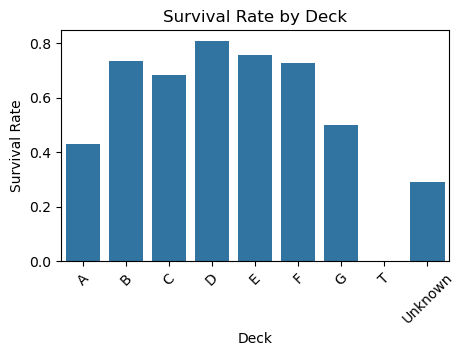

In [17]:
# Plot X_train Deck survival rate
def plot_deck_survival_rate(X_df, y_df):
    """
    Plots the survival rate by Deck.
    
    Parameters:
    - X_df: DataFrame containing the features
    - y_df: Series containing the target values
    """
    if 'Deck' not in X_df.columns:
        print("Deck feature not found in the DataFrame.")
        return
    
    deck_survival = pd.concat([X_df['Deck'], y_df], axis=1)
    deck_survival = deck_survival.groupby('Deck')['Survived'].mean().reset_index()
    
    plt.figure(figsize=(5, 3))
    sns.barplot(x='Deck', y='Survived', data=deck_survival)
    plt.title('Survival Rate by Deck')
    plt.xlabel('Deck')
    plt.ylabel('Survival Rate')
    plt.xticks(rotation=45)
    plt.show()

X_train_deck = X_train[['Cabin']].copy()
X_train_deck['Deck'] = X_train_deck['Cabin'].str[0].fillna('Unknown')
plot_deck_survival_rate(X_train_deck, y_train)

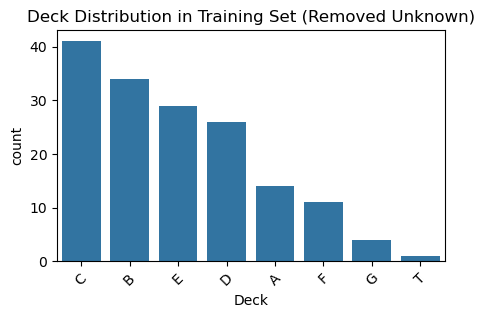

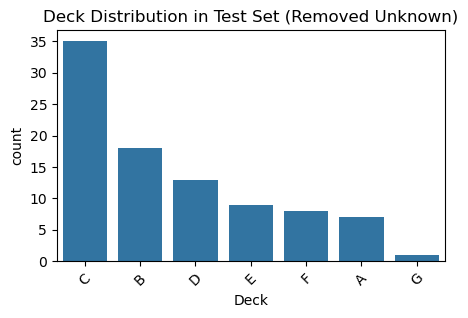

In [18]:
# Plot Train vs Test Deck values
X_train_deck = X_train[['Cabin']].copy()
X_test_deck = X_test[['Cabin']].copy()
X_train_deck['Deck'] = X_train_deck['Cabin'].str[0]
X_test_deck['Deck'] = X_test_deck['Cabin'].str[0]

plt.figure(figsize=(5, 3))
sns.countplot(x='Deck', data=X_train_deck, order=X_train_deck['Deck'].value_counts().index) 
plt.title('Deck Distribution in Training Set (Removed Unknown)')
plt.xticks(rotation=45) 
plt.show()  
plt.figure(figsize=(5, 3))
sns.countplot(x='Deck', data=X_test_deck, order=X_test_deck['Deck'].value_counts().index) 
plt.title('Deck Distribution in Test Set (Removed Unknown)')
plt.xticks(rotation=45) 
plt.show()

#### Family Size

Passenger family sizes have a non-linear relationship with survival:
* More passengers traveling alone perished rather than survived.
* Roughly equal number of passengers traveling with one family member perished and survived.
* More passengers with 2 or 3 family members survived rather than perished.
* Majority of passengers with 4 or more family members perished.

<Figure size 500x300 with 0 Axes>

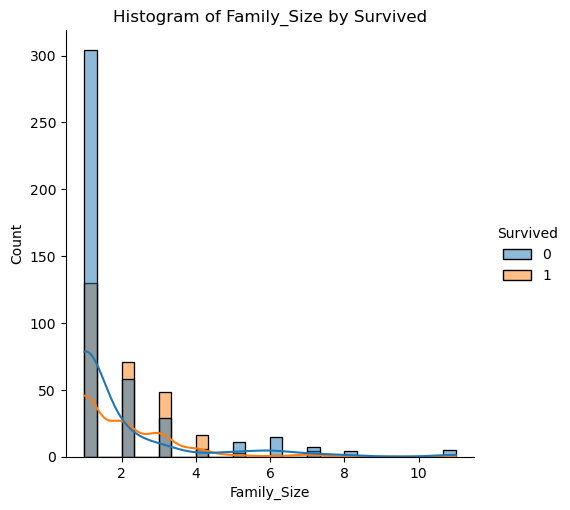

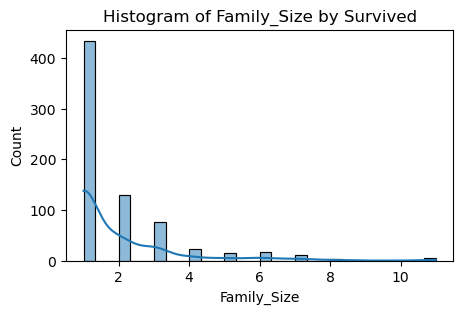

In [19]:
X_train_family_size = X_train[['Parch', 'SibSp']].copy()
X_train_family_size['Family_Size'] = X_train_family_size['Parch'] + X_train_family_size['SibSp'] + 1
visualize_feature(X_train_family_size, 'Family_Size', y_train)
visualize_feature(X_train_family_size, 'Family_Size')

#### Sex x Is_Alone

* Non-linear survival rates observed for passengers traveling alone or with family, across genders.
* Females with family survived at significantly higher rate (0.78) than males with family (0.27)

In [20]:
X_train_isalone_pclass = X_train[['Parch', 'SibSp', 'Sex']].copy()
X_train_isalone_pclass['Is_Alone'] = ((X_train_family_size['Parch'] + X_train_family_size['SibSp'] + 1) == 1).astype(int)
comb_df = pd.concat([X_train_isalone_pclass, y_train], axis=1)
# Pivot table: Survival Rate by Is_Alone and Pclass
pivot = comb_df.pivot_table(
    index='Is_Alone',
    columns='Sex',
    values='Survived',
    aggfunc='mean'
)
pivot = pivot.rename_axis('Is_Alone').rename_axis('Sex', axis=1)
pivot


Sex,female,male
Is_Alone,,
0,0.717105,0.269841
1,0.782178,0.153153


### Feature Engineering

#### Feature Creation

In [21]:
def engineer_features(df):

    # Create Sex_Encoded feature
    # df['Sex_Encoded'] = df['Sex'].map({'male': 0, 'female': 1})

    # Create Deck feature from CabinCabin
    df['Deck'] = df['Cabin'].str[0]

    # Fill missing Deck values with 'U' for Unknown
    df['Deck'] = df['Deck'].fillna('U')

    # Create Deck_Bin feature
    def bin_deck(deck):
        if deck in ['A', 'B', 'C']:
            return 'Upper'
        elif deck in ['D', 'E']:
            return 'Middle'
        elif deck in ['F', 'G', 'T']:
            return 'Rare'
        else:
            return 'Unknown_Deck'
    df['Deck_Bin'] = df['Deck'].apply(bin_deck)

    # Create Title feature from Name
    def extract_title(name):
        title = name.split(',')[1].split('.')[0].strip()
        return title
    df['Title'] = df['Name'].apply(extract_title)

    # Create Family Size feature
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
    def bin_family_size(size):
        if size <= 2:
            return f"{size}"
        elif size <= 4:
            return '3-4'
        else:
            return '5+'
    df['Family_Size_Bin'] = df['Family_Size'].apply(bin_family_size)
    
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

    df['Sex_Pclass_IsAlone'] = df['Sex'].astype(str) + '_' + df['Pclass'].astype(str) + '_' + df['Is_Alone'].astype(str)

    df['Pclass_Sex'] = df['Pclass'].astype(str) + '_' + df['Sex'].astype(str)

    return df


In [22]:
X_train = engineer_features(X_train)

#### Pipeline Imputers

* Mode and median calculations are used to impute the missing `Embarked` and `Age` values.
* Custom imputer classes are created so that the calculations are confined to only the training set/fold when evaluating models during Training and Cross Validation.

In [23]:
class AgeImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        df = pd.DataFrame(X).copy()
        # compute medians on training fold only
        self.pclass_title_median_ = (
            df.groupby(['Pclass','Title'])['Age']
              .median()
              .rename('median')
              .reset_index()
        )
        self.sex_median_ = (
            df.groupby('Sex')['Age']
              .median()
              .rename('median')
              .reset_index()
        )
        return self

    def transform(self, X):
        df = pd.DataFrame(X).copy()

        # helper to look up from pclass_title_median_
        def fill_pt(row):
            if pd.notna(row['Age']):
                return row['Age']
            mask = (
                (self.pclass_title_median_['Pclass']==row['Pclass']) &
                (self.pclass_title_median_['Title']==row['Title'])
            )
            val = self.pclass_title_median_[mask]['median']
            return float(val.iloc[0]) if not val.empty else row['Age']

        df['Age'] = df.apply(fill_pt, axis=1)

        # fallback to sex median
        def fill_sex(row):
            if pd.notna(row['Age']):
                return row['Age']
            mask = self.sex_median_['Sex']==row['Sex']
            return float(self.sex_median_[mask]['median'].iloc[0])
        df['Age'] = df.apply(fill_sex, axis=1)
        return df #[['Age']]
    
# NOTE: AgeBinner will pass through 'Age' as well as any column not specified in 'drop_cols'
class AgeBinner(BaseEstimator, TransformerMixin):
    def __init__(self, bins, labels=None, drop_cols=None, right=True):
        """
        bins : list of edges, e.g. [0, 10, 17, 35, 55, np.inf]
        labels : list of labels of length len(bins)-1
        right : whether intervals include the right edge
        """
        self.bins = bins
        self.labels = labels
        self.right = right
        self.drop_cols = drop_cols

    def fit(self, X, y=None):
        # nothing to learn
        return self

    def transform(self, X):
        df = pd.DataFrame(X).copy()
        # apply pd.cut to the 'Age' column
        df['Age_Bin'] = pd.cut(
            df['Age'],
            bins=self.bins,
            labels=self.labels,
            right=self.right
        )
        if self.drop_cols is not None:
            # Drop specified columns to prevent them from being OHEC'd later
            df.drop(columns=self.drop_cols, inplace=True)
        return df

class EmbarkedImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        # no hyper‐parameters here
        pass

    def fit(self, X, y=None):
        """
        X: array‐like or DataFrame with columns ['Pclass','Embarked']
        """
        df = pd.DataFrame(X, columns=['Pclass','Embarked'])
        # compute the mode of Embarked for each Pclass
        # .mode() returns a Series (possibly multiple modes), so take the first [0]
        self.pclass_mode_ = (
            df
            .dropna(subset=['Embarked'])
            .groupby('Pclass')['Embarked']
            .agg(lambda s: s.mode().iloc[0])
            .to_dict()
        )
        return self

    def transform(self, X):
        df = pd.DataFrame(X, columns=['Pclass','Embarked']).copy()

        def _fill(row):
            if pd.notna(row['Embarked']):
                return row['Embarked']
            # lookup the Pclass‐mode, or fall back to overall mode
            return self.pclass_mode_.get(row['Pclass'],
                                        max(self.pclass_mode_.values(),
                                            key=lambda v: list(self.pclass_mode_.values()).count(v))
                                       )

        df['Embarked'] = df.apply(_fill, axis=1)
        return df

class TicketFrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ticket_counts_ = None

    def fit(self, X, y=None):
        X_df = self._ensure_dataframe(X, ['Ticket'])
        self.ticket_counts_ = X_df['Ticket'].value_counts().to_dict()
        return self

    def transform(self, X):
        X_df = self._ensure_dataframe(X, ['Ticket'])
        X_df['Ticket_Frequency'] = X_df['Ticket'].map(self.ticket_counts_).fillna(1)
        return X_df[['Fare', 'Ticket_Frequency']]

    def get_feature_names_out(self, input_features=None):
        return np.array(['Fare', 'Ticket_Frequency'])

    def _ensure_dataframe(self, X, columns):
        if isinstance(X, pd.DataFrame):
            return X
        return pd.DataFrame(X, columns=columns)

# Create FareImputer that takes median of passengers in same Pclass and Embarked
class FareImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.pclass_embarked_median_ = None

    def fit(self, X, y=None):
        X_df = self._ensure_dataframe(X, ['Ticket', 'Fare', 'Embarked', 'Pclass'])
        self.pclass_embarked_median_ = (
            X_df.groupby(['Pclass', 'Embarked'])['Fare']
            .median()
            .rename('median')
            .reset_index()
        )
        return self
    
    def transform(self, X):
        X_df = self._ensure_dataframe(X, ['Ticket', 'Fare', 'Embarked', 'Pclass'])
        def fill_fare(row):
            if pd.notna(row['Fare']):
                return row['Fare']
            mask = (
                (self.pclass_embarked_median_['Pclass'] == row['Pclass']) &
                (self.pclass_embarked_median_['Embarked'] == row['Embarked'])
            )
            val = self.pclass_embarked_median_[mask]['median']
            return float(val.iloc[0]) if not val.empty else row['Fare']
        X_df['Fare'] = X_df.apply(fill_fare, axis=1)
        return X_df
    
    def _ensure_dataframe(self, X, columns):
        if isinstance(X, pd.DataFrame):
            return X
        return pd.DataFrame(X, columns=columns)
    
class FarePerPersonTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        self.is_fitted_ = True  # Flag to indicate to framework that this transformer is fitted (needs at least one attr ending with '_')
        return self

    def transform(self, X):
        X_df = self._ensure_dataframe(X, ['Fare', 'Ticket_Frequency'])
        X_df = X_df.copy()
        X_df.loc[:, 'Fare_Per_Person'] = np.log1p(X_df['Fare']) / X_df['Ticket_Frequency'].replace(0, 1)
        return X_df[['Fare_Per_Person', 'Ticket_Frequency']]
    
    def get_feature_names_out(self, input_features=None):
        return np.array(['Fare_Per_Person', 'Ticket_Frequency'])

    def _ensure_dataframe(self, X, columns):
        if isinstance(X, pd.DataFrame):
            return X
        return pd.DataFrame(X, columns=columns)
    
class FeatureDropper(BaseEstimator, TransformerMixin):
    def __init__(self, drop_features=None):
        self.drop_features = drop_features or []
        self.keep_indices_ = None

    def fit(self, X, y=None):
        # If X is a DataFrame, we can directly use column names
        if hasattr(X, 'columns'):
            feature_names = X.columns
        else:
            # Try to get feature names from the input estimator
            # This is typically passed manually from preprocessor.get_feature_names_out()
            if hasattr(self, 'input_feature_names_'):
                feature_names = self.input_feature_names_
            else:
                raise ValueError("FeatureDropper requires DataFrame input or .input_feature_names_ to be set.")

        self.keep_indices_ = [i for i, name in enumerate(feature_names) if name not in self.drop_features]
        return self

    def transform(self, X):
        if self.drop_features is None or len(self.drop_features) == 0:
            print("✅ No features to drop. Returning input unchanged.")
        else:
            print(f"✂️ Dropping features: {self.drop_features}")
            
        if isinstance(X, pd.DataFrame):
            return X.drop(columns=self.drop_features)
        elif isinstance(X, np.ndarray):
            return X[:, self.keep_indices_]
        elif hasattr(X, 'toarray'):
            return X[:, self.keep_indices_].toarray()
        else:
            raise TypeError(f"Unsupported input type. Expected DataFrame or NumPy array: {type(X)}")

    def set_input_feature_names(self, feature_names):
        self.input_feature_names_ = feature_names  

class MultiColumnBinner(BaseEstimator, TransformerMixin):
    def __init__(self, bin_specs, input_features=None):
        """
        bin_specs: dict of format
        {
            'column_name': {
                'bins': [...],
                'labels': [...]
            }
        }
        input_features: list of column names (used to convert ndarray to DataFrame)
        """
        self.bin_specs = bin_specs
        self.input_features = input_features

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Convert ndarray to DataFrame using provided column names
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
        elif self.input_features is not None:
            X_df = pd.DataFrame(X, columns=self.input_features)
        else:
            raise ValueError("input_features must be provided when input is an ndarray")

        for col, spec in self.bin_specs.items():
            X_df[f"{col}_bin"] = pd.cut(
                X_df[col],
                bins=spec['bins'],
                labels=spec['labels'],
                include_lowest=True
            ).astype(str)

        return X_df[[f"{col}_bin" for col in self.bin_specs]]
    
    def get_feature_names_out(self, input_features=None):
        return np.array([f"{col}_bin" for col in self.bin_specs])


In [24]:
exclusion_features = ['Name', 'Cabin', 'PassengerId', 'Ticket_Number']
meaningful_features = [feature for feature in X_train.columns.tolist() if feature not in exclusion_features]
print(f"Meaningful features: {meaningful_features}")

Meaningful features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'Deck', 'Deck_Bin', 'Title', 'Family_Size', 'Family_Size_Bin', 'Is_Alone', 'Sex_Pclass_IsAlone', 'Pclass_Sex']


### Model Development

In [25]:
def get_feature_names_from_preprocessor(preprocessor, selected_features):
    """Extract feature names after preprocessing."""
    feature_names = []
    
    for name, transformer, features in preprocessor.transformers_:
        if name == 'scaler' or name == 'passthrough' or name == 'loner_p3_male_southampton':
            feature_names.extend(features)
        elif name == 'fpp' or name == 'sex_isalone_ohe':
            if hasattr(transformer, 'named_steps'):
                ohe = transformer.named_steps.get('ohe', None)
                if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                    ohe_names = ohe.get_feature_names_out()
                    feature_names.extend(ohe_names)
                else:
                    categories = ohe.categories_ if ohe is not None else []
                    for i, feature in enumerate(features):
                        for cat in categories[i]:
                            feature_names.append(f"{feature}_{cat}")
            else:
                feature_names.extend(features)
        elif name == 'loner_p3_male_southampton_young_adult_pipeline':
            feature_names.extend(['Is_Loner_P3_Male_Southampton_Young_Adult'])
        elif name == 'p1_loner_male_young_adult_pipeline':
            feature_names.extend(['Is_P1_Loner_Male_Young_Adult'])
        elif name == 'sex_isalone_ohes_and_male_loner_teen_pipeline':
            feature_names.extend(['Sex_IsAlone_female_1', 'Sex_IsAlone_male_0', 'Sex_IsAlone_male_1', 'Sex_IsAlone_male_1_Teen'])
        elif name == 'onehot':
            if hasattr(transformer, 'get_feature_names_out'):
                ohe_names = transformer.get_feature_names_out(features)
                feature_names.extend(ohe_names)
            else:
                categories = []
                for i, feature in enumerate(features):
                    cats = transformer.categories_[i]
                    for cat in cats:
                        categories.append(f"{feature}_{cat}")
                feature_names.extend(categories)
        elif name == 'fare_log_ohe':
            if hasattr(transformer, 'named_steps'):
                ohe = transformer.named_steps.get('ohe', None)
                if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                    ohe_names = ohe.get_feature_names_out(features)
                    feature_names.extend(ohe_names)
                else:
                    categories = ohe.categories_ if ohe is not None else []
                    for i, feature in enumerate(features):
                        for cat in categories[i]:
                            feature_names.append(f"{feature}_{cat}")
            else:
                feature_names.extend(features)
        elif name == 'age_ohe':
            if hasattr(transformer, 'named_steps'):
                ohe = transformer.named_steps.get('ohe_age', None)
                if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                    ohe_names = ohe.get_feature_names_out()
                    feature_names.extend(ohe_names)
                else:
                    categories = ohe.categories_ if ohe is not None else []
                    for i, feature in enumerate(features):
                        for cat in categories[i]:
                            feature_names.append(f"{feature}_{cat}")
            else:
                feature_names.extend(features)
        elif name == 'pclass_embarked_ohe':
            if hasattr(transformer, 'named_steps'):
                ohe = transformer.named_steps.get('ohe_embarked', None)
                if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                    ohe_names = ohe.get_feature_names_out() # Intentionally pass None to default to ohe.feature_names_in_
                    feature_names.extend(ohe_names)
                else:
                    categories = ohe.categories_ if ohe is not None else []
                    for i, feature in enumerate(features):
                        for cat in categories[i]:
                            feature_names.append(f"{feature}_{cat}")
            else:
                feature_names.extend(features)
        elif name == 'class_sex_embarked_age_isalone_pipeline' or name == 'pclass_isalone_ohe':
            ohe = transformer.named_steps.get('ohe', None)
            if ohe is not None and hasattr(ohe, 'get_feature_names_out'):
                ohe_names = ohe.get_feature_names_out() # Intentionally pass None to default to ohe.feature_names_in_
                feature_names.extend(ohe_names)
            else:
                categories = ohe.categories_ if ohe is not None else []
                for i, feature in enumerate(features):
                    for cat in categories[i]:
                        feature_names.append(f"{feature}_{cat}")
    return feature_names


In [26]:
def deduplicate_df_majority_label(df, target='target'):
    duplicates = df.duplicated(keep=False)
    print(f"Original Training Set: {len(df)} rows.")
    if duplicates.any():
        print(f"⚠️ Found {duplicates.sum()} duplicate rows in the training set.")
    else:
        print("✅ No duplicate rows found in the training set.")

    feature_columns = list(df.columns[:-1])  
    
    grouped_results = []
    for name, group in df.groupby(feature_columns, observed=True):
        resolved_target = group[target].mode().iloc[0]
        
        # Create a single row with all feature values plus resolved target
        if isinstance(name, tuple):
            row_dict = dict(zip(feature_columns, name))
        else:
            row_dict = {feature_columns[0]: name}
        row_dict[target] = resolved_target
        grouped_results.append(row_dict)
    
    resolved_df = pd.DataFrame(grouped_results)
    
    print(f"✅ Resolved duplicates: {len(resolved_df)} unique rows after deduplication.")
    return resolved_df

In [27]:
class DupFreeClassifier(BaseEstimator, ClassifierMixin):
    """
    Collapses duplicate rows in the training set and resolves conflicts by taking the majority class.
    This is useful to prevent information leakage from the holdout set during cross-validation.

    Assumes the base_estimator supports the sample_weight parameter.
    """
    def __init__(self, base_estimator):
        self.base_estimator = base_estimator

    def __getstate__(self):
        """Support for pickling"""
        state = self.__dict__.copy()
        return state
    
    def __setstate__(self, state):
        """Support for unpickling"""
        self.__dict__.update(state) 

    def get_params(self, deep=True):
        """Get parameters for this estimator and the wrapped estimator."""
        params = super().get_params(deep=False)
        if deep and hasattr(self, 'base_estimator'):
            base_params = self.base_estimator.get_params(deep=True)
            # Prefix base estimator parameters
            for key, value in base_params.items():
                params[f'base_estimator__{key}'] = value
        return params
    
    def set_params(self, **params):
        """Set parameters for this estimator and the wrapped estimator."""
        # Separate parameters for this wrapper vs the base estimator
        wrapper_params = {}
        base_params = {}
        
        for key, value in params.items():
            if key.startswith('base_estimator__'):
                # Remove prefix and set on base estimator
                base_key = key[len('base_estimator__'):]
                base_params[base_key] = value
            else:
                # Set on this wrapper
                wrapper_params[key] = value
        
        # Set base estimator parameters
        if base_params and hasattr(self, 'base_estimator'):
            self.base_estimator.set_params(**base_params)
        
        # Set wrapper parameters
        super().set_params(**wrapper_params)
        return self     
        
    def fit(self, X, y, **fit_params):
        #print(f"Fitting {self.__class__.__name__}...")
        try:
            if hasattr(X, 'toarray'):
                X_dense = X.toarray()
            else:
                X_dense = X

            # Mark as fitted for sklearn
            self.fitted_ = True  # Add this line

            df = pd.DataFrame(X_dense).copy()
            y_arr = np.asarray(y).ravel() 
            df['target'] = y_arr

            dedupe = fit_params.pop('dedupe', True)
            if  dedupe == True:
                print("\nDedupe flag is set. Checking for duplicates in the training set...")

                # TODO If needed, use a more robust method than majority label to resolve duplicates
                df = deduplicate_df_majority_label(df)
            else:
                print("Deduplication deactivated. No deduplication performed.")
            feature_columns = list(df.columns[:-1])
            X_clean = df[feature_columns].copy()
            y_clean = df['target'].values

            print(f"Saving clean training set for later use... ({len(X_clean)} rows, {len(feature_columns)} features)")
            self.train_X_clean_ = X_clean.copy()

            self.estimator_ = clone(self.base_estimator)
            self.estimator_.fit(X_clean, y_clean, **fit_params)
            return self
        except Exception as e:
            print(f"Error during fitting {self.__class__.__name__}: {e}")
            raise

    def predict(self, X):
        print(f"Saving clean predicted set for post-analysis... ({X.shape[0]} rows)")
        self.predicted_X_clean = X.copy()
        return self.estimator_.predict(X)

    def predict_proba(self, X):
        print(f"Saving clean predicted set for post-analysis... ({X.shape[0]} rows)")
        self.predicted_X_clean = X.copy()
        return self.estimator_.predict_proba(X)

    def __getattr__(self, name):
        try:
            #print(f"Accessing attribute '{name}' of {type(self).__name__}")
            if 'estimator_' in self.__dict__:
                retval = getattr(self.estimator_, name)
                #print(f"Returning attribute '{name}' from estimator: {retval}")
                return retval
            elif 'base_estimator' in self.__dict__:
                retval = getattr(self.base_estimator, name)
                #print(f"Returning attribute '{name}' from base_estimator: {retval}")
                return retval
            else:
                #print(f"Attribute '{name}' not found in {type(self).__name__} or its base_estimator.")
                raise AttributeError(f"'{type(self).__name__}' object has no attribute '{name}'")
        except Exception as e:
            #print(f"Error accessing attribute '{name}': {e}")
            raise e

In [28]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    cm_counts = confusion_matrix(y_true, y_pred)
    mlflow.log_metric("cm_false_positive_pct", cm[0, 1])
    mlflow.log_metric("cm_false_negative_pct", cm[1, 0])

    # Annotate with both percent and count
    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]:.2%}\n({cm_counts[i, j]})"

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                xticklabels=['Not Survived', 'Survived'],
                yticklabels=['Not Survived', 'Survived'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix\n(Percent, Count)')
    plt.show()

In [29]:
def evaluate_model(pipeline, X, y, selected_features, deduplicate_X=True, threshold=None, training_baseline_metrics=None, skip_visualizations=False, log_model=False):
    
    print("\n" + "="*50)
    print("MODEL EVALUATION")
    print("="*50)

    # Combine X and y into a DataFrame
    df = pd.DataFrame(X[selected_features]).copy()
    df['y_true'] = y

    if deduplicate_X == True:

        # Deduplicate by feature columns, resolving conflicts by taking mode of y
        grouped = df.groupby(selected_features, sort=False)['y_true'].agg(lambda x: x.mode().iloc[0])
        X_dedup = grouped.index.to_frame(index=False).reset_index(drop=True)
        y_dedup = grouped.reset_index(drop=True)

        print(f"\nOriginal Prediction Set: {len(X)} rows.")
        print(f"✅ Deduplicated data: {len(X_dedup)} unique rows after deduplication post-processing.")
    else:
        # If not deduplicating, just use the original data
        print(f"\nSkipping deduplication and using original data: {len(X)} rows.")
        X_dedup = df.copy()
        y_dedup = y

    # Predict using the pipeline
    y_pred_proba = pipeline.predict_proba(X_dedup)[:, 1]
    print(f"Model outputted predictions for {len(y_pred_proba)} rows.")  # Show first 5 predictions
    if threshold is not None:
        mlflow.log_param("proba_threshold", threshold)
        print(f"Using threshold: {threshold:.3f}")
        y_pred = (y_pred_proba >= threshold).astype(int)
    else:
        y_pred = pipeline.predict(X_dedup)

    if skip_visualizations is not True:
        print(f"\nDetailed Classification Report:")
        print(classification_report(y_dedup, y_pred, target_names=['Not Survived', 'Survived'], zero_division=0))

        # Confusion matrix
        plot_confusion_matrix(y_dedup, y_pred)

    # Compute metrics
    metrics = {
        'log_loss': log_loss(y_dedup, y_pred_proba),
        'pr_auc': average_precision_score(y_dedup, y_pred_proba),
        'f1': f1_score(y_dedup, y_pred, average='macro', zero_division=0),
        'precision': precision_score(y_dedup, y_pred, average='macro', zero_division=0),
        'recall': recall_score(y_dedup, y_pred, average='macro', zero_division=0),
        'accuracy': accuracy_score(y_dedup, y_pred),
    }
    mlflow.log_metrics(metrics)

    print("\n📈 Model Scores:")
    if training_baseline_metrics is not None:
        log_loss_diff = metrics['log_loss'] - training_baseline_metrics['log_loss']
        print(f"Log Loss: {metrics['log_loss']:.4f} (Diff from Baseline: {log_loss_diff:.4f})")
        pr_auc_diff = metrics['pr_auc'] - training_baseline_metrics['pr_auc']
        print(f"PR AUC: {metrics['pr_auc']:.4f} (Diff from Baseline: {pr_auc_diff:.4f})")
        f1_diff = metrics['f1'] - training_baseline_metrics['f1']
        print(f"F1 Score: {metrics['f1']:.4f} (Diff from Baseline: {f1_diff:.4f})")
        precision_diff = metrics['precision'] - training_baseline_metrics['precision']
        print(f"Precision: {metrics['precision']:.4f} (Diff from Baseline: {precision_diff:.4f})")
        recall_diff = metrics['recall'] - training_baseline_metrics['recall']
        print(f"Recall: {metrics['recall']:.4f} (Diff from Baseline: {recall_diff:.4f})")
        accuracy_diff = metrics['accuracy'] - training_baseline_metrics['accuracy']
        print(f"Accuracy: {metrics['accuracy']:.4f} (Diff from Baseline: {accuracy_diff:.4f})")
        
        variance_metrics = {
            'log_loss_diff': log_loss_diff,
            'pr_auc_diff': pr_auc_diff,
            'f1_diff': f1_diff,
            'precision_diff': precision_diff,
            'recall_diff': recall_diff,
            'accuracy_diff': accuracy_diff
        }
        mlflow.log_metrics(variance_metrics)

    else:
        print(f"Log Loss: {metrics['log_loss']:.4f}")
        print(f"PR AUC: {metrics['pr_auc']:.4f}")
        print(f"F1 Score: {metrics['f1']:.4f}")
        print(f"Precision: {metrics['precision']:.4f}")
        print(f"Recall: {metrics['recall']:.4f}")
        print(f"Accuracy: {metrics['accuracy']:.4f}")

    ################## PR Curve + PR AUC
    precision, recall, thresholds = precision_recall_curve(y_dedup, y_pred_proba)
    avg_precision = average_precision_score(y_dedup, y_pred_proba)

    best_f1_threshold = None
    if skip_visualizations is not True:
        plt.figure(figsize=(8, 6))
        plt.plot(recall, precision, label=f'PR Curve (AP = {avg_precision:.3f})')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall (PR) Curve')
        plt.grid(True)
        plt.legend()
        plt.show()

        precision, recall, thresholds = precision_recall_curve(y_dedup, y_pred_proba)
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)  # avoid div-by-zero
        best_idx = np.argmax(f1_scores)
        best_f1_threshold = thresholds[best_idx]

        print(f"ℹ️ Best threshold for F1 score: {best_f1_threshold:.3f}")
        print(f"Max F1 score: {f1_scores[best_idx]:.3f}")

    if log_model == True:
        print("Logging model to MLflow...")
        model_signature = infer_signature(X_dedup, y_pred)
        input_example = X_dedup.iloc[:5]
        mlflow.sklearn.log_model(pipeline, "model", signature=model_signature, input_example=input_example, registered_model_name="TitanicSurvivalModel")

    return metrics, best_f1_threshold, pipeline.named_steps['classifier'].predicted_X_clean, y_dedup, y_pred, y_pred_proba

#### Stage 1: Bias Optimization

In [30]:
mlflow.set_tracking_uri('http://ec2-3-136-156-127.us-east-2.compute.amazonaws.com:5000/')
#mlflow.set_tracking_uri('http://localhost:5000/')
mlflow.set_experiment('titanic_ml_from_disaster__abridged')
ohe_features = ['Family_Size_Bin', 'Deck_Bin', 'Pclass_Sex'] 
selected_features = ['Pclass', 'Sex', 'Ticket', 'Age', 'Fare', 'Title', 'Embarked'] + ohe_features 
high_corr_features_to_drop_postprocessing = [
    
]

In [31]:
def create_preprocessor(ohe_features):
    """Create a preprocessor pipeline with feature engineering and encoding."""
    bin_specs = {

        'Ticket_Frequency': {
            'bins': [-float('inf'), 1.5, 2.5, float('inf')],
            'labels': ['Solo', 'Pair', 'Group']
        },
        'Fare_Per_Person': {
            'bins': [-float('inf'), 1.0, 2.5, float('inf')],
            'labels': ['Low', 'Mid', 'High']
        }
    }

    # Create Ticket_Frequency and Fare_Per_Person bin OHEs
    fare_enrichment_pipeline = Pipeline([
        ('fare_imputer', FareImputer()),
        ('ticket_freq', TicketFrequencyEncoder()),
        ('fare_per_person', FarePerPersonTransformer()),
        ('ticketfreq_fpp_binning', MultiColumnBinner(bin_specs=bin_specs, input_features=['Ticket_Frequency', 'Fare_Per_Person'])),
        ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first')) 
    ])

    # Impute Embarked then create Pclass_Embarked OHEs
    def create_pclass_embarked_feature(X):
        df = pd.DataFrame(X, columns=['Pclass', 'Embarked'])
        df['Pclass_Embarked'] = df['Pclass'].astype(str) + '_' + df['Embarked'].astype(str)
        return df[['Pclass_Embarked']]
    pclass_embarked_pipeline = Pipeline([
        ('impute_embarked', EmbarkedImputer()),
        ('create_pclass_embarked', FunctionTransformer(create_pclass_embarked_feature, validate=False)),
        ('ohe_embarked', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    # Impute Age then create Age bin OHEs
    bins = [0, 10, 25, 40, 55, 100]
    mlflow.log_param("age_bins", bins)
    labels = ['Child', 'Teen', 'Young_Adult', 'Middle_Aged', 'Senior']
    age_pipeline_cols = ['Pclass', 'Title', 'Sex', 'Age']
    age_pipeline = Pipeline([
        ('impute_age', AgeImputer()),  
        ('bin_age', AgeBinner(bins=bins, labels=labels, drop_cols=age_pipeline_cols)),
        ('ohe_age', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])

    optimal_threshold = 0.341

    return ColumnTransformer([
        ('fpp', fare_enrichment_pipeline, ['Ticket', 'Fare', 'Embarked', 'Pclass']),
        ('pclass_embarked_ohe', pclass_embarked_pipeline, ['Pclass', 'Embarked']),
        ('age_ohe', age_pipeline, age_pipeline_cols),  
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'), ohe_features)
    ]), optimal_threshold


PREPROCESSING AND TRAINING
Preprocessor will generate 27 features after preprocessing.
✅ No features to drop. Returning input unchanged.

Dedupe flag is set. Checking for duplicates in the training set...
Original Training Set: 712 rows.
⚠️ Found 493 duplicate rows in the training set.
✅ Resolved duplicates: 281 unique rows after deduplication.
Saving clean training set for later use... (281 rows, 27 features)

Checking for multicollinearity in the processed training set...
✅ No high correlation pairs found (|r| <= 0.8).

Preprocessor generated the following 27 features:
* Ticket_Frequency_bin_Pair
* Ticket_Frequency_bin_Solo
* Fare_Per_Person_bin_Low
* Fare_Per_Person_bin_Mid
* Pclass_Embarked_1_Q
* Pclass_Embarked_1_S
* Pclass_Embarked_2_C
* Pclass_Embarked_2_Q
* Pclass_Embarked_2_S
* Pclass_Embarked_3_C
* Pclass_Embarked_3_Q
* Pclass_Embarked_3_S
* Age_Bin_Middle_Aged
* Age_Bin_Senior
* Age_Bin_Teen
* Age_Bin_Young_Adult
* Family_Size_Bin_2
* Family_Size_Bin_3-4
* Family_Size_Bin_5

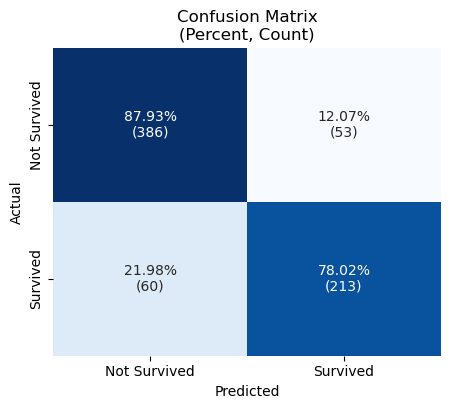


📈 Model Scores:
Log Loss: 0.4217
PR AUC: 0.8457
F1 Score: 0.8313
Precision: 0.8331
Recall: 0.8297
Accuracy: 0.8413


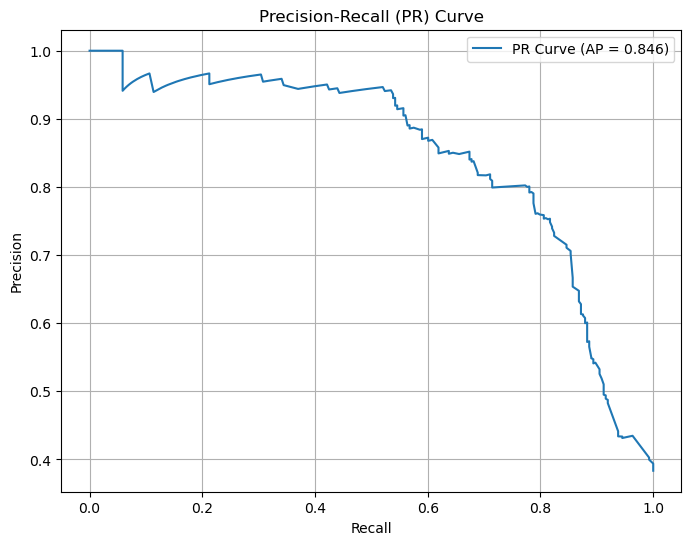

ℹ️ Best threshold for F1 score: 0.341
Max F1 score: 0.790

Non-Zero Coefficients:
                           Coefficient
Pclass_Sex_2_female           1.130737
Family_Size_Bin_3-4           0.689456
Pclass_Embarked_1_Q           0.105873
Pclass_Embarked_1_S           0.075371
Family_Size_Bin_2            -0.060143
Pclass_Embarked_2_Q          -0.098089
Ticket_Frequency_bin_Pair    -0.120503
Pclass_Embarked_3_C          -0.179988
Pclass_Embarked_2_C          -0.280217
Ticket_Frequency_bin_Solo    -0.385011
Deck_Bin_Upper               -0.426256
Fare_Per_Person_bin_Mid      -0.427662
Family_Size_Bin_5+           -0.467215
Pclass_Embarked_2_S          -0.528254
Pclass_Sex_3_female          -0.559996
Deck_Bin_Rare                -0.568039
Age_Bin_Teen                 -0.676327
Pclass_Embarked_3_Q          -0.724404
Fare_Per_Person_bin_Low      -0.788969
Age_Bin_Young_Adult          -0.831431
Age_Bin_Middle_Aged          -0.956449
Pclass_Embarked_3_S          -1.164990
Deck_Bin_Unknown_Deck

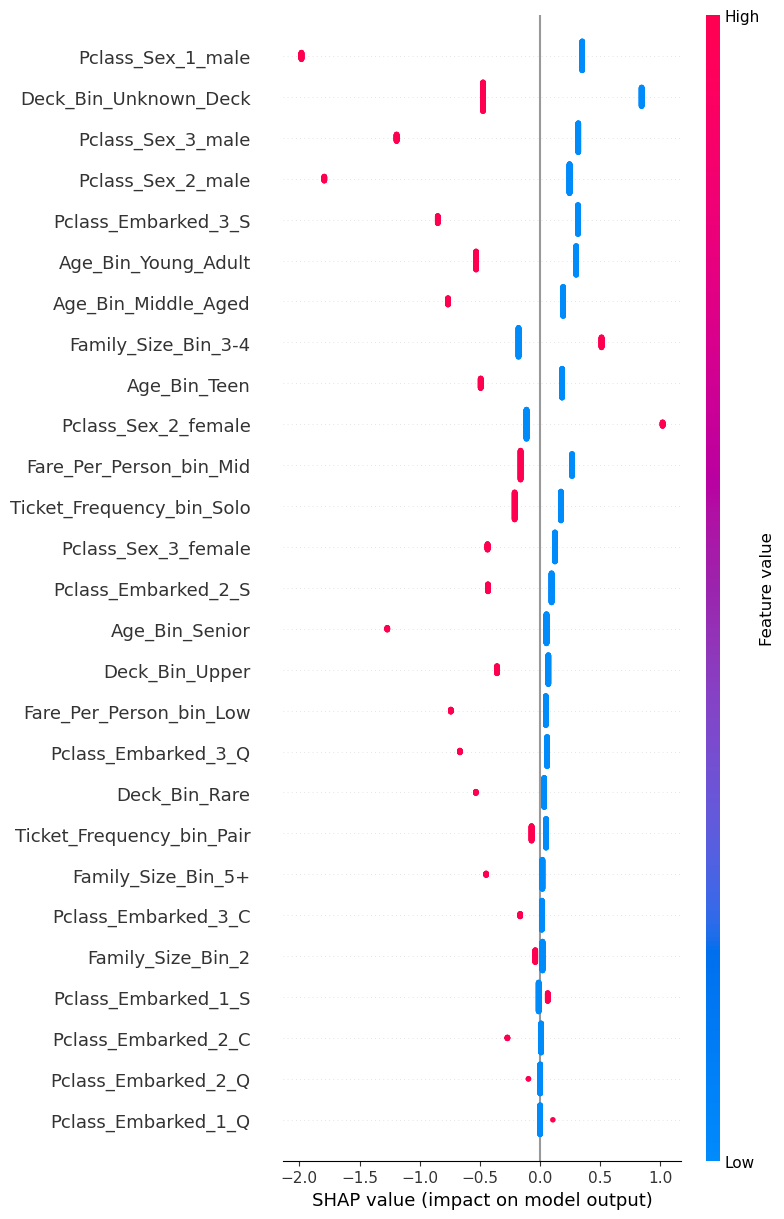

In [32]:
mlflow.end_run()
with mlflow.start_run():
    mlflow.set_tag("dataset", "X_train")

    print("\n" + "="*50)
    print("PREPROCESSING AND TRAINING")
    print("="*50)

    preprocessor, optimal_threshold = create_preprocessor(ohe_features)

    # These params were obtained from Stage 2 Generalization Optimization (Took hyperparameters that minimized log-loss across 3-fold CV)
    optimized_model_params = {'C': 0.7920818753959785, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 430, 'penalty': 'l2', 'solver': 'saga'}

    preprocessor.fit(X_train)
    feature_names_after_preprocessing = get_feature_names_from_preprocessor(preprocessor, selected_features)
    feature_names_after_preprocessing = [feat for feat in feature_names_after_preprocessing if feat not in high_corr_features_to_drop_postprocessing]
    print(f"Preprocessor will generate {len(feature_names_after_preprocessing)} features after preprocessing.")
    dropper = FeatureDropper(drop_features=high_corr_features_to_drop_postprocessing)
    dropper.set_input_feature_names(feature_names_after_preprocessing)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('dropper', dropper),
        ('classifier', DupFreeClassifier(LogisticRegression(**optimized_model_params, random_state=42)))
    ])

    mlflow.log_param("model_type", pipeline.named_steps['classifier'].__class__.__name__)
    mlflow.log_params(optimized_model_params)

    # Defer calibrating model probabilities to Stage 2 (CV) given Stage 1 focus on model bias optimization
    pipeline.fit(X_train[selected_features], y_train)

    # Plot correlation matrix for fitted features to identify potential multicollinearity issues
    # Print feature pairs with high correlation (> 0.8)
    X_train_processed = pipeline.named_steps['classifier'].train_X_clean_
    X_train_processed.columns = feature_names_after_preprocessing
    print("\nChecking for multicollinearity in the processed training set...")
    correlation_matrix = X_train_processed.corr()
    high_corr_pairs = []
    for i in range(len(feature_names_after_preprocessing)):
        for j in range(i + 1, len(feature_names_after_preprocessing)):
            if abs(correlation_matrix.iloc[i, j]) > 0.8:
                high_corr_pairs.append((feature_names_after_preprocessing[i], feature_names_after_preprocessing[j], correlation_matrix.iloc[i, j]))
    if high_corr_pairs:
        print("⚠️ High Correlation Pairs (|r| > 0.8):")
        for feat1, feat2, corr in high_corr_pairs:
            print(f"* {feat1} and {feat2}: {corr:.2f}") 
    else:
        print("✅ No high correlation pairs found (|r| <= 0.8).") 

    print(f"\nPreprocessor generated the following {len(feature_names_after_preprocessing)} features:")
    for i, feat in enumerate(feature_names_after_preprocessing):
        print(f"* {feat}")
        mlflow.log_param(f"feature_{i}", feat)

    baseline_scores, best_f1_threshold, X_predicted_csr_matrix, y_true, y_pred, y_pred_proba = evaluate_model(pipeline, X_train, y_train, selected_features, threshold=optimal_threshold, deduplicate_X=False)
 
    print("\nNon-Zero Coefficients:")
    coef_df = pd.DataFrame(pipeline.named_steps['classifier'].coef_.T, index=feature_names_after_preprocessing, columns=['Coefficient'])
    non_zero_coefs = coef_df[coef_df['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)
    zero_coefs = coef_df[coef_df['Coefficient'] == 0]
    print(non_zero_coefs)

    if optimized_model_params['penalty'] == 'l1':
        print("\nZeroed-out Coefficients:")
        print(zero_coefs)


    explainer = shap.LinearExplainer(pipeline.named_steps['classifier'], X_train_processed)
    shap_values = explainer.shap_values(X_train_processed)
    shap.summary_plot(shap_values, X_train_processed, plot_type="dot", show=False, max_display=len(X_train_processed.columns))

#### Training Set Prediction Mistake Analysis

* Confusion matrix shows model has low recall of the minority positive class `Survived=1`.
* We take a closer look at the training samples where `Survived=1` to see what feature engineering we can introduce to help the model recognize survivors.

In [33]:
X_train[selected_features].shape, X_predicted_csr_matrix.shape, y_true.shape, y_pred.shape, y_pred_proba.shape

((712, 10), (712, 27), (712,), (712,), (712,))

In [34]:
X_predicted = pd.DataFrame(X_predicted_csr_matrix, columns=feature_names_after_preprocessing)
training_prediction_results_df = pd.concat([
    X_predicted.reset_index(drop=True),
    pd.Series(y_true, name='y_true').reset_index(drop=True),
    pd.Series(y_pred, name='y_pred').reset_index(drop=True),
    pd.Series(y_pred_proba, name='y_pred_proba').reset_index(drop=True)
], axis=1)

training_prediction_results_df['Mistake'] = training_prediction_results_df['y_true'] !=  training_prediction_results_df['y_pred']
training_prediction_results_df['Mistake_Prob'] = np.abs(training_prediction_results_df['y_pred_proba'] - training_prediction_results_df['y_true'])
survived_pred_results_df = training_prediction_results_df[training_prediction_results_df['y_true'] == 1]
perished_pred_results_df = training_prediction_results_df[training_prediction_results_df['y_true'] == 0]
print(f"Mistake Rate of Perished Passengers: {perished_pred_results_df['Mistake'].mean():.2%} ({perished_pred_results_df['Mistake'].sum()})")
print(f"Mistake Rate of Survived Passengers: {survived_pred_results_df['Mistake'].mean():.2%} ({survived_pred_results_df['Mistake'].sum()})")

Mistake Rate of Perished Passengers: 12.07% (53)
Mistake Rate of Survived Passengers: 21.98% (60)


##### Correct vs Mistake Feature Distribution Comparison

Large spike in high-log-loss mistakes suggests model has blind spot to survival subgroup(s).

C:\Users\pault\AppData\Local\Temp\ipykernel_31400\2353809310.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


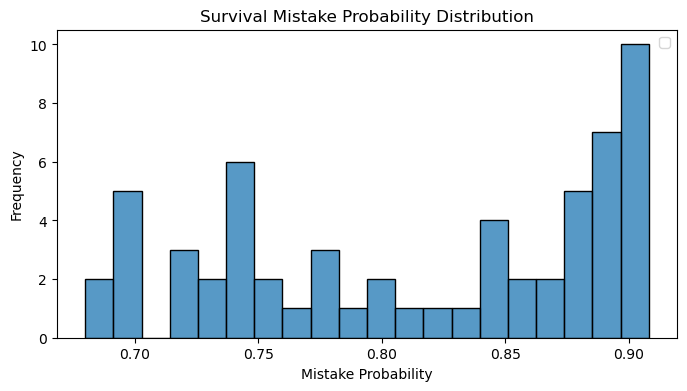

C:\Users\pault\AppData\Local\Temp\ipykernel_31400\2353809310.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


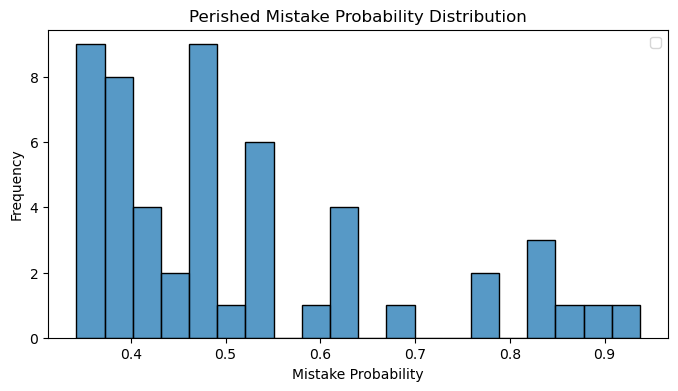

In [35]:
# Separate Mistakes from Correct Predictions for distribution comparison
survived_pred_results_df_mistakes = survived_pred_results_df[survived_pred_results_df['Mistake'] == True]
survived_pred_results_df_correct = survived_pred_results_df[survived_pred_results_df['Mistake'] == False]
perished_pred_results_df_mistakes = perished_pred_results_df[perished_pred_results_df['Mistake'] == True]
perished_pred_results_df_correct = perished_pred_results_df[perished_pred_results_df['Mistake'] == False]

# Probability Distribution of Mistaken Predictions of Survived Passengers
plt.figure(figsize=(8, 4))
sns.histplot(survived_pred_results_df_mistakes['Mistake_Prob'], bins=20)
plt.title('Survival Mistake Probability Distribution')
plt.xlabel('Mistake Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Probability Distribution of Mistaken Predictions of Survived Passengers
plt.figure(figsize=(8, 4))
sns.histplot(perished_pred_results_df_mistakes['Mistake_Prob'], bins=20)
plt.title('Perished Mistake Probability Distribution')
plt.xlabel('Mistake Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

C:\Users\pault\AppData\Local\Temp\ipykernel_31400\29260383.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


High-Confidence Mistakes (Mistake_Prob > 0.8): 34


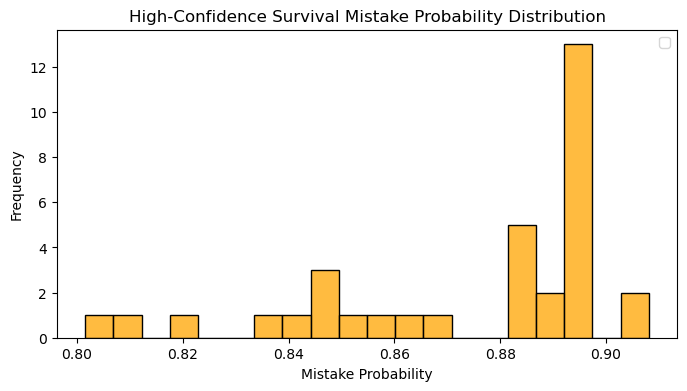

In [36]:
# Separating highest-confidence mistakes and comparing distribution to Correct predictions to see if any differences
mistake_proba_theshold = 0.8
high_confidence_mistakes = survived_pred_results_df_mistakes[survived_pred_results_df_mistakes['Mistake_Prob'] > mistake_proba_theshold]
print(f"High-Confidence Mistakes (Mistake_Prob > {mistake_proba_theshold}): {len(high_confidence_mistakes)}")

# Probability Distribution of High-Confidence Mistakes of Survived Passengers
plt.figure(figsize=(8, 4))
sns.histplot(high_confidence_mistakes['Mistake_Prob'], bins=20, color='orange')
plt.title('High-Confidence Survival Mistake Probability Distribution')
plt.xlabel('Mistake Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

##### Feature Predictiveness of High-Confidence Mistakes

A LogisticRegression model is trained with base features and `Mistake` as target in order to use coefficients to identify features that helped and hurt model predictiveness.

In [37]:
X = survived_pred_results_df[(survived_pred_results_df['Mistake'] == False) | (survived_pred_results_df['Mistake_Prob'] > mistake_proba_theshold)]
y = X['Mistake'].astype(int)
X = X.drop(columns=['Mistake', 'Mistake_Prob', 'y_pred', 'y_pred_proba', 'y_true'])
mistake_lr = LogisticRegression(
                C=1.0, 
                class_weight='balanced', 
                fit_intercept=True, 
                max_iter=100, 
                penalty='l2', 
                
                solver='liblinear', 
                random_state=42
            )
mistake_lr.fit(X, y)

print(f"\nLogistic Regression Coefficients for High-Confidence Mistake Prediction (Mistake_Prob > {mistake_proba_theshold}):")
mistake_coef_df = pd.DataFrame(mistake_lr.coef_.T, index=X.columns, columns=['Coefficient'])
mistake_coef_df.sort_values(by='Coefficient', ascending=False, inplace=True)
mistake_coef_df


Logistic Regression Coefficients for High-Confidence Mistake Prediction (Mistake_Prob > 0.8):


,Coefficient
Pclass_Embarked_3_S,1.938381
Pclass_Sex_2_male,1.772533
Deck_Bin_Unknown_Deck,1.744169
Pclass_Sex_3_male,1.622158
Family_Size_Bin_5+,0.832853
Pclass_Sex_1_male,0.769795
Age_Bin_Senior,0.601806
Age_Bin_Young_Adult,0.421984
Fare_Per_Person_bin_Low,0.284371
Fare_Per_Person_bin_Mid,0.268591


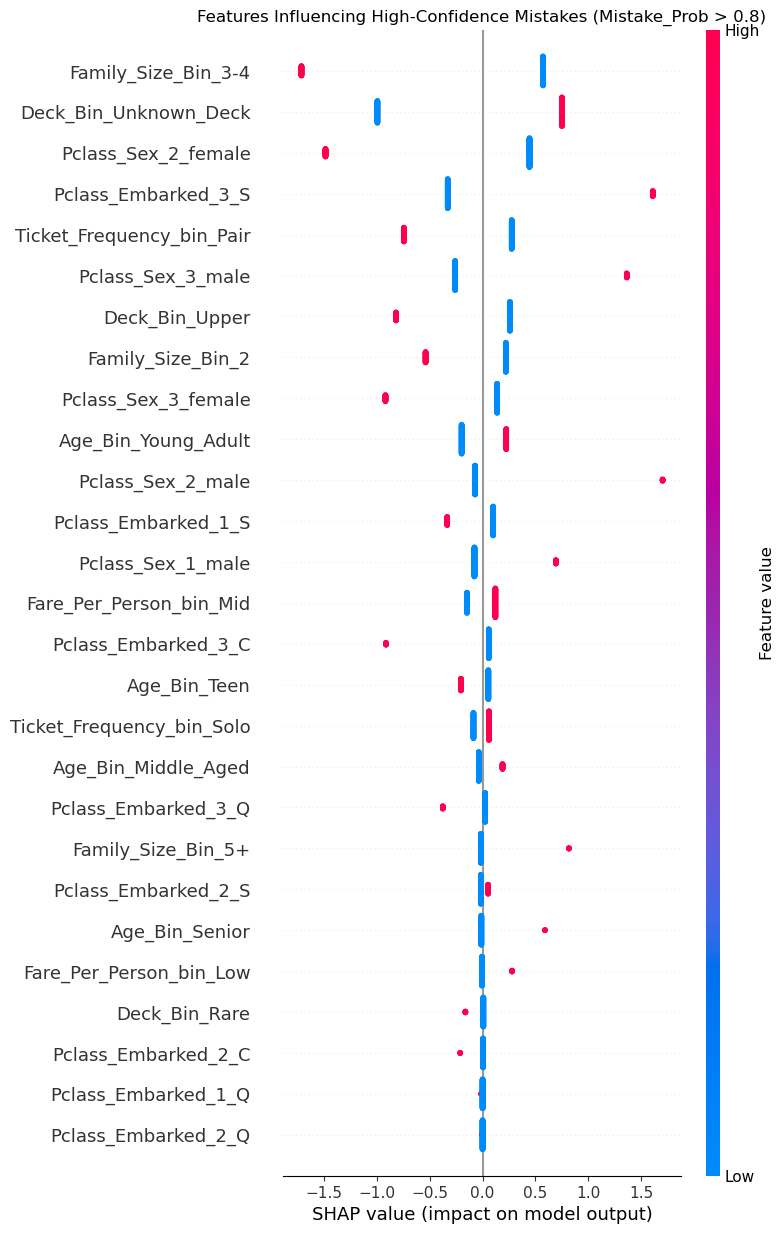


Top 5 Features by Influence High-Confidence Survival Prediction Mistake Probability:
* Pclass_Embarked_3_S: 1.9384
* Pclass_Sex_2_male: 1.7725
* Deck_Bin_Unknown_Deck: 1.7442
* Pclass_Sex_3_male: 1.6222
* Family_Size_Bin_5+: 0.8329


In [38]:
explainer = shap.LinearExplainer(mistake_lr, X)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X, plot_type="dot", show=False, max_display=len(X.columns))
plt.title(f"Features Influencing High-Confidence Mistakes (Mistake_Prob > {mistake_proba_theshold})")
plt.show()

# List features with largest positive SHAP values in decreasing order
print("\nTop 5 Features by Influence High-Confidence Survival Prediction Mistake Probability:")
top_positive_features_influencing_mistakes = mistake_coef_df[mistake_coef_df['Coefficient'] > 0].sort_values(by='Coefficient', ascending=False).head(5)
for feature, coef in top_positive_features_influencing_mistakes.itertuples(index=True):
    print(f"* {feature}: {coef:.4f}")

##### Model Mis-Predictions EDA

* Mistake-trained Logistic Regression model coefficients used to identify the features contributing the most to the survival model's prediction errors ("mistakes").
* These features identify subgroups where further feature engineering is waranted to increase the model's visibility to surviving passengers.
* Top 3 features driving survival mis-predictions are summarized below:

| Feature Name | Passenger Characteristic | Survival Model Learned to..| Increased Mistake Probability implies ... | Survival Precision | Survival Recall | Mis-Predicted Survivors (FP) | Missed Survivors (FN) |
| ------------ | -------------- | ------------------------------------ | ----------------- | ------------ | ------- | ------ | ---- |
| `Pclass_Embarked_3_S` | 3rd class Southampton passengers | Decrease survival chance | Subgroup(s) on 3rd class Southamptonians survived | 0.67 | 0.23 | 6 | 41|
| `Pclass_Sex_2_male` | 2nd class males | Decrease survival chance | Subgroup(s) of 2nd class males survived | 0.82 | 0.64 | 5 | 2 |
| `Deck_Bin_Unknown_Deck` | Passengers not given Deck assigment | Decrease survival chance | Subgroups of passengers without decks survived | 0.83 | 0.66 | 21 | 55 |
| `Pclass_Sex_3_male` | 3rd class males | Decrease survival chance | Subgroup(s) of 2nd class males survived | 0.78 | 0.19 | 2 | 30 |
| `Family_Size_Bin_5+` | Passengers with large families | Decrease survival chance | Subgroup(s) with large families survived | 1.00 | 0.50 | 0 | 4 |



Evaluating subgroup: Pclass_Embarked_3_S
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       233
           1       0.67      0.23      0.34        53

    accuracy                           0.84       286
   macro avg       0.76      0.60      0.62       286
weighted avg       0.81      0.84      0.80       286



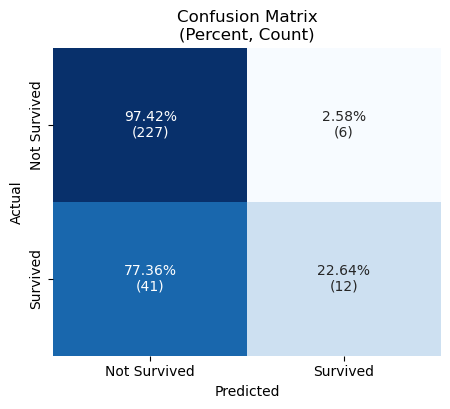


Evaluating subgroup: Pclass_Sex_2_male
              precision    recall  f1-score   support

           0       0.94      0.97      0.96        78
           1       0.82      0.64      0.72        14

    accuracy                           0.92        92
   macro avg       0.88      0.81      0.84        92
weighted avg       0.92      0.92      0.92        92



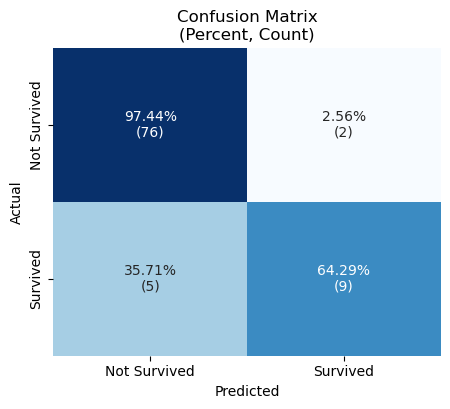


Evaluating subgroup: Deck_Bin_Unknown_Deck
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       391
           1       0.83      0.66      0.74       161

    accuracy                           0.86       552
   macro avg       0.85      0.80      0.82       552
weighted avg       0.86      0.86      0.86       552



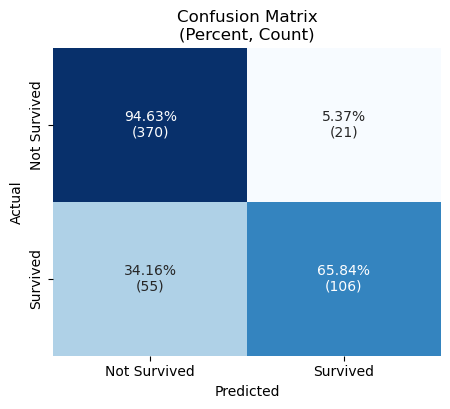


Evaluating subgroup: Pclass_Sex_3_male
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       238
           1       0.78      0.19      0.30        37

    accuracy                           0.88       275
   macro avg       0.83      0.59      0.62       275
weighted avg       0.87      0.88      0.85       275



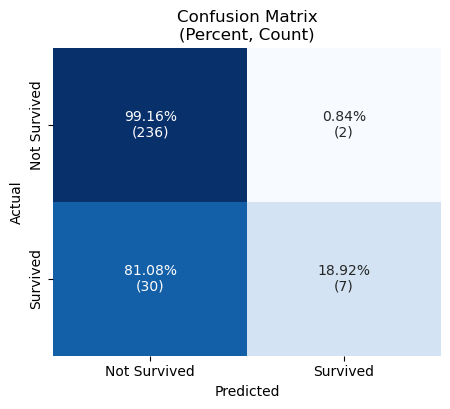


Evaluating subgroup: Family_Size_Bin_5+
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        42
           1       1.00      0.50      0.67         8

    accuracy                           0.92        50
   macro avg       0.96      0.75      0.81        50
weighted avg       0.93      0.92      0.91        50



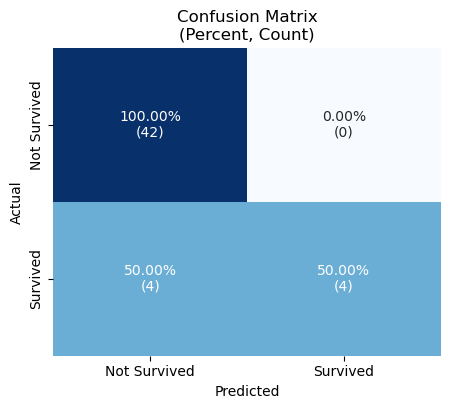

In [39]:
# Investigate precision / recall performance of top features predicting mistakes to identify next steps
for subgroup_to_inspect in top_positive_features_influencing_mistakes.index:
    print(f"\nEvaluating subgroup: {subgroup_to_inspect}")
    subgroup_df = training_prediction_results_df[training_prediction_results_df[subgroup_to_inspect] == 1].copy()
    print(classification_report(subgroup_df['y_true'], subgroup_df['y_pred'], zero_division=0))
    plot_confusion_matrix(subgroup_df['y_true'], subgroup_df['y_pred'])


In [40]:
# Compare distribution of age features between correct and mistaken predictions
# for age_feature in ['Fare_Per_Person_bin_Low', 'Fare_Per_Person_bin_Mid']:
#     plt.figure(figsize=(10, 6))
#     sns.kdeplot(subgroup_df[subgroup_df['Mistake'] == False][age_feature], label='Correct Predictions', fill=True, alpha=0.5)
#     sns.kdeplot(subgroup_df[subgroup_df['Mistake'] == True][age_feature], label='Mistaken Predictions', fill=True, alpha=0.5)
#     plt.title(f'Age Feature Distribution: {age_feature}')
#     plt.xlabel('Value')
#     plt.ylabel('Density')
#     plt.legend()
#     plt.show()

In [41]:
# Perform subgroup EDA on full preprocessed training set to identify new features to engineer
preprocessed_training_prediction_results_df = pd.concat([
    X_train.reset_index(drop=True),
    pd.Series(y_true, name='y_true').reset_index(drop=True),
    pd.Series(y_pred, name='y_pred').reset_index(drop=True),
    pd.Series(y_pred_proba, name='y_pred_proba').reset_index(drop=True)
], axis=1)

# Filter preprocessed training set to only include subgroup to analyze (do not deduplicate for now to simplify EDA)
preprocessed_training_prediction_results_df = engineer_features(preprocessed_training_prediction_results_df)
passengers_with_unknown_deck = preprocessed_training_prediction_results_df[preprocessed_training_prediction_results_df['Deck_Bin'] == 'Unknown_Deck'].copy()
passengers_with_unknown_deck['Mistake'] = passengers_with_unknown_deck['y_true'] != passengers_with_unknown_deck['y_pred']
passengers_with_unknown_deck.rename(columns={'y_true': 'Survived'}, inplace=True)

survived_male_loners_df = passengers_with_unknown_deck[passengers_with_unknown_deck['Survived'] == 1].copy()
missed_survived_male_loners_df = passengers_with_unknown_deck[passengers_with_unknown_deck['Mistake'] == 1].copy()
print(f"Male Loners to analyze: {len(passengers_with_unknown_deck)} rows")
print(passengers_with_unknown_deck['Survived'].value_counts())
print(passengers_with_unknown_deck['Survived'].value_counts(normalize=True))

# Create Fare_log, Ticket Frequency and FPP
def engineer_eda_features(df):
    """Engineer additional features for EDA."""
    df['Fare_log'] = np.log1p(df['Fare'])
    ticket_counts = df['Ticket'].value_counts().to_dict()
    df['Ticket_Frequency'] = df['Ticket'].map(ticket_counts).fillna(1)
    df['Ticket_Number'] = df['Ticket'].str.extract(r'(\d+)$')
    df['Fare_Per_Person'] = df['Fare'] / df['Ticket_Frequency']
    df['Fare_log_Per_Person'] = df['Fare_log'] / df['Ticket_Frequency']
    df['Fare_log_Per_Person_Scaled'] = StandardScaler().fit_transform(df['Fare_log_Per_Person'].values.reshape(-1, 1))
    df['Is_AboveAverage_Scaled_Fare_log_and_Known_Deck'] = (
        (df['Fare_log_Per_Person_Scaled'] > df['Fare_log_Per_Person_Scaled'].mean()) &
        (df['Deck_Bin'] !='Unknown_Deck')
    ).astype(int)
    return df
preprocessed_training_prediction_results_df = engineer_eda_features(preprocessed_training_prediction_results_df)
passengers_with_unknown_deck = engineer_eda_features(passengers_with_unknown_deck)


Male Loners to analyze: 552 rows
Survived
0    391
1    161
Name: count, dtype: int64
Survived
0    0.708333
1    0.291667
Name: proportion, dtype: float64


In [42]:
# Compare distribution of features between correct and mistaken predictions
#features_to_compare = ['Age', 'Fare', 'Ticket_Frequency', 'Fare_Per_Person', 'Fare_log', 'Fare_log_Per_Person', 'Survived']
# features_to_compare = passengers_with_unknown_deck.columns.difference(['Survived', 'y_true', 'y_pred', 'y_pred_proba', 'Mistake', 'Ticket', 'Ticket_Number', 'Name', 'Cabin', 'PassengerId'])
# for feature in features_to_compare:
#     plt.figure(figsize=(8, 4))
#     if pd.api.types.is_numeric_dtype(passengers_with_unknown_deck[feature]):
#         sns.boxplot(
#             data=passengers_with_unknown_deck,
#             x='Mistake',
#             y=feature
#         )
#         plt.title(f"Distribution of {feature} by Mistake Status (Continuous)")
#     else:
#         sns.countplot(
#             data=passengers_with_unknown_deck,
#             x=feature,
#             hue='Mistake'
#         )
#         plt.title(f"Countplot of {feature} by Mistake Status (Categorical)")
#     plt.show()

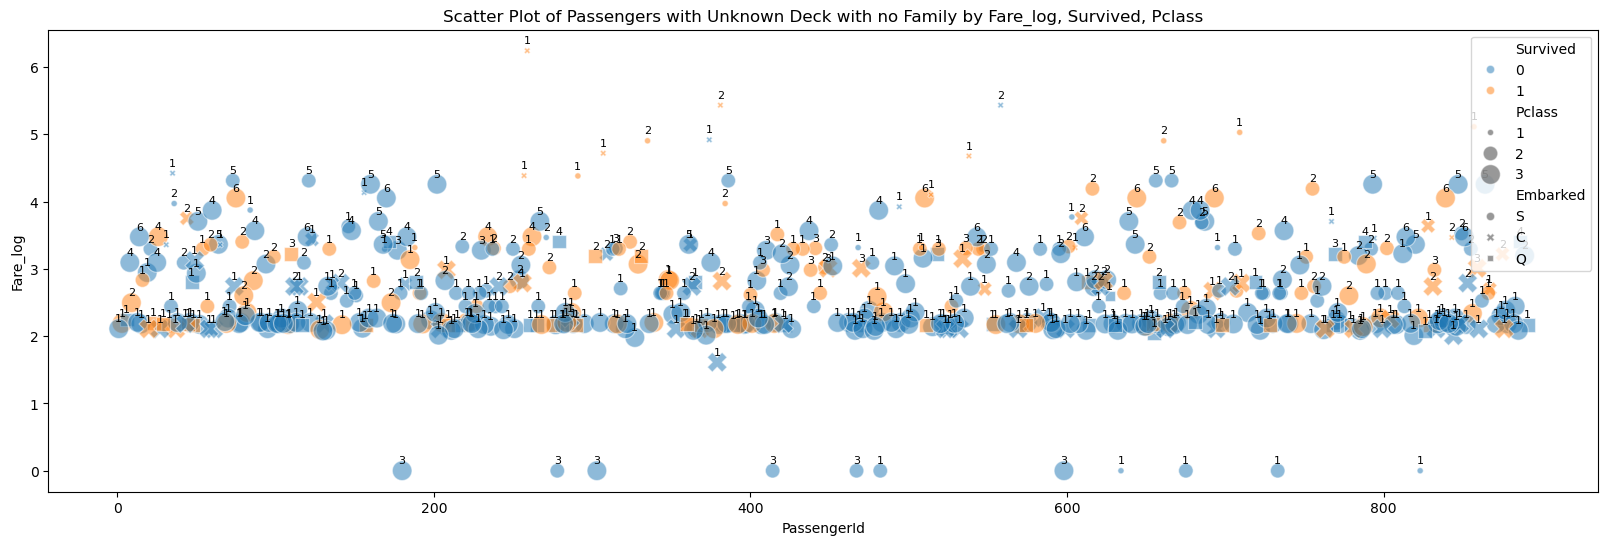

In [43]:
# Example Subgroup Scatterplot Analysis: Investigate patterns between survival and other features amongst Passengers with Unknown Deck
# Change these to manipulate the scatterplot
dataset_to_assess = passengers_with_unknown_deck # survived_male_loners_df, p3_male_loners_df
hue_to_assess = 'Survived' # Mistake, Survived
y_axis_col = 'Fare_log'
x_axis_col = 'PassengerId'

plt.figure(figsize=(20, 6))
ax = sns.scatterplot(
    data=dataset_to_assess,
    x=x_axis_col,
    y=y_axis_col,
    hue=hue_to_assess,
    size="Pclass",
    sizes=(20, 200),
    style="Embarked",
    alpha=0.5
)
plt.title(f"Scatter Plot of Passengers with Unknown Deck with no Family by {y_axis_col}, {hue_to_assess}, Pclass")
plt.xlabel(x_axis_col)
plt.ylabel(y_axis_col)
plt.legend()

# Annotate each point with Ticket_Frequency
for _, row in dataset_to_assess.iterrows():
    ax.annotate(
        str(row["Ticket_Frequency"]),
        (row[x_axis_col], row[y_axis_col]),
        textcoords="offset points",
        xytext=(0, 5),
        ha='center',
        fontsize=8,
        color='black'
    )

plt.show()


76 mistakes in Family_Size_Bin_5+ subgroup.


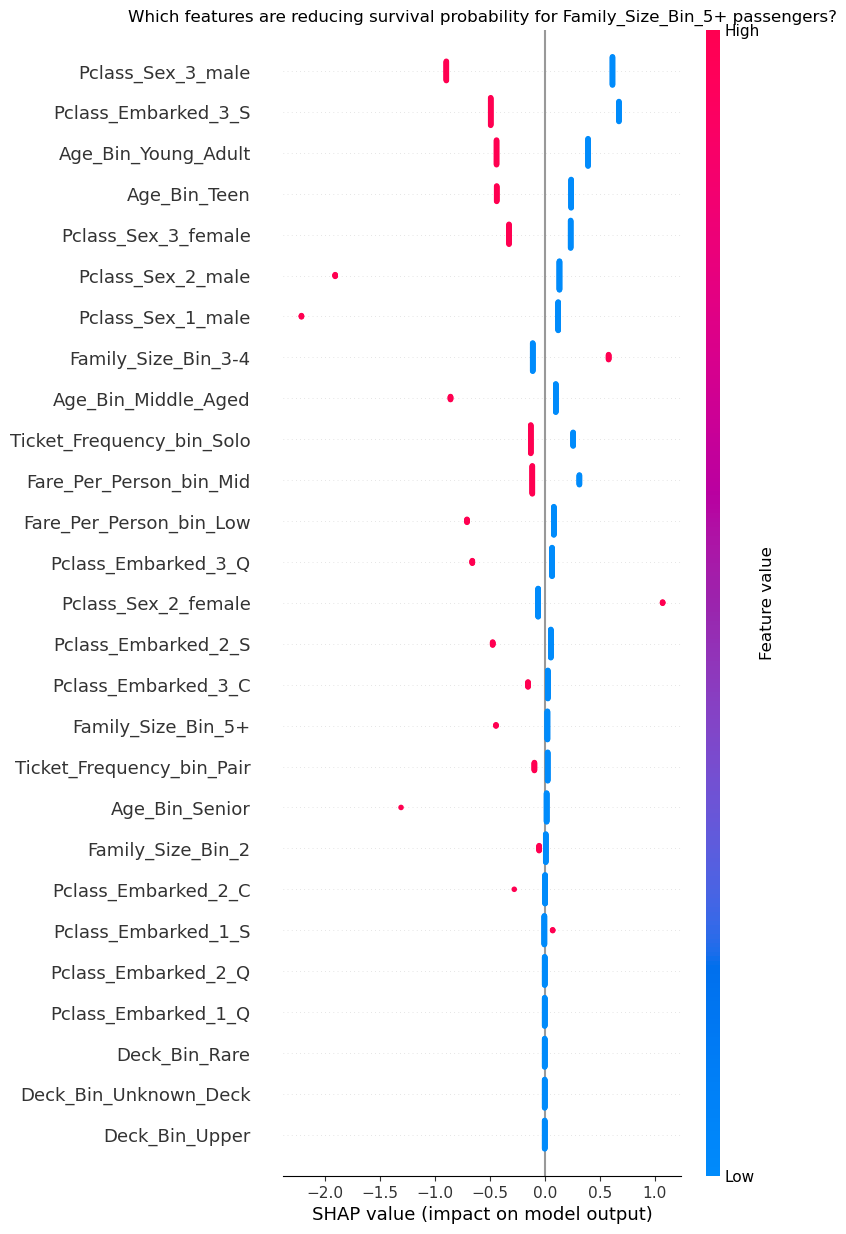

In [44]:
# # Example Subgroup SHAP Analysis: Investigate which features are hurting recall for this subgroup
# Example Next Step:  Creating iteraction features between Sex_IsAlone_male_1 and these features to see if they improve recall
subgroup_df = training_prediction_results_df[training_prediction_results_df['Deck_Bin_Unknown_Deck'] == 1].copy()
subgroup_df_mistakes = subgroup_df[subgroup_df['Mistake'] == True]
print(f"\n{len(subgroup_df_mistakes)} mistakes in {subgroup_to_inspect} subgroup.")
mistake_analysis_X = subgroup_df_mistakes.drop(columns=['y_true', 'y_pred', 'y_pred_proba', 'Mistake', 'Mistake_Prob'])
explainer = shap.LinearExplainer(pipeline.named_steps['classifier'], mistake_analysis_X)
shap_values = explainer.shap_values(mistake_analysis_X)
shap.summary_plot(shap_values, mistake_analysis_X, plot_type="dot", show=False, max_display=len(mistake_analysis_X.columns))
plt.title(f'Which features are reducing survival probability for {subgroup_to_inspect} passengers?')
plt.show()

#### Stage 2: Generalization Optimization

🏃 View run whimsical-duck-528 at: http://ec2-3-136-156-127.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/770fc13a19104ee9bb32c642fe3157fc
🧪 View experiment at: http://ec2-3-136-156-127.us-east-2.compute.amazonaws.com:5000/#/experiments/3

Fold 1/3


[I 2025-06-29 12:44:57,165] A new study created in memory with name: titanic_ml_from_disaster__abridged_fold_1



PREPROCESSING AND TRAINING
Preprocessor will generate 27 features after preprocessing.
✅ No features to drop. Returning input unchanged.

Dedupe flag is set. Checking for duplicates in the training set...
Original Training Set: 474 rows.
⚠️ Found 315 duplicate rows in the training set.
✅ Resolved duplicates: 211 unique rows after deduplication.
Saving clean training set for later use... (211 rows, 27 features)

MODEL EVALUATION

Original Prediction Set: 474 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✅ No features to drop. Returning input unchanged.
Saving clean predicted set for post-analysis... (382 rows)
Model outputted predictions for 382 rows.


c:\Users\pault\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[I 2025-06-29 12:44:58,027] Trial 0 finished with value: 0.3881825424827561 and parameters: {'C': 64.75531353682683, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 245, 'penalty': 'l1', 'solver': 'saga'}. Best is trial 0 with value: 0.3881825424827561.


Using threshold: 0.341

📈 Model Scores:
Log Loss: 0.3882
PR AUC: 0.8704
F1 Score: 0.8175
Precision: 0.8146
Recall: 0.8243
Accuracy: 0.8220
Preprocessor will generate 27 features after preprocessing.
✅ No features to drop. Returning input unchanged.

Dedupe flag is set. Checking for duplicates in the training set...
Original Training Set: 474 rows.
⚠️ Found 315 duplicate rows in the training set.
✅ Resolved duplicates: 211 unique rows after deduplication.
Saving clean training set for later use... (211 rows, 27 features)

MODEL EVALUATION

Original Prediction Set: 474 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✅ No features to drop. Returning input unchanged.
Saving clean predicted set for post-analysis... (382 rows)
Model outputted predictions for 382 rows.


...


📈 Model Scores:
Log Loss: 0.4500
PR AUC: 0.8372
F1 Score: 0.7981
Precision: 0.7977
Recall: 0.8102
Accuracy: 0.8010
Preprocessor will generate 27 features after preprocessing.
✅ No features to drop. Returning input unchanged.

Dedupe flag is set. Checking for duplicates in the training set...
Original Training Set: 474 rows.
⚠️ Found 315 duplicate rows in the training set.
✅ Resolved duplicates: 211 unique rows after deduplication.
Saving clean training set for later use... (211 rows, 27 features)

MODEL EVALUATION

Original Prediction Set: 474 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✅ No features to drop. Returning input unchanged.
Saving clean predicted set for post-analysis... (382 rows)
Model outputted predictions for 382 rows.


[I 2025-06-29 12:45:21,102] Trial 28 finished with value: 0.3934571474207509 and parameters: {'C': 4.35764802388471, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 883, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 22 with value: 0.38377421326746713.


Using threshold: 0.341

📈 Model Scores:
Log Loss: 0.3935
PR AUC: 0.8659
F1 Score: 0.8127
Precision: 0.8101
Recall: 0.8211
Accuracy: 0.8168
Preprocessor will generate 27 features after preprocessing.
✅ No features to drop. Returning input unchanged.

Dedupe flag is set. Checking for duplicates in the training set...
Original Training Set: 474 rows.
⚠️ Found 315 duplicate rows in the training set.
✅ Resolved duplicates: 211 unique rows after deduplication.
Saving clean training set for later use... (211 rows, 27 features)

MODEL EVALUATION

Original Prediction Set: 474 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✅ No features to drop. Returning input unchanged.
Saving clean predicted set for post-analysis... (382 rows)
Model outputted predictions for 382 rows.


[I 2025-06-29 12:45:21,866] Trial 29 finished with value: 0.38439879004969224 and parameters: {'C': 41.509797432774775, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 761, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 22 with value: 0.38377421326746713.


Using threshold: 0.341

📈 Model Scores:
Log Loss: 0.3844
PR AUC: 0.8709
F1 Score: 0.8276
Precision: 0.8247
Recall: 0.8330
Accuracy: 0.8325
Best Trial:
  Value (Log Loss): 0.3838
  Params:
    C: 21.393058582593838
    class_weight: balanced
    fit_intercept: True
    max_iter: 897
    penalty: l2
    solver: liblinear

Checking for multicollinearity in the processed training set...
✅ No high correlation pairs found (|r| <= 0.8).

Preprocessor generated the following 27 features:
* Ticket_Frequency_bin_Pair
* Ticket_Frequency_bin_Solo
* Fare_Per_Person_bin_Low
* Fare_Per_Person_bin_Mid
* Pclass_Embarked_1_Q
* Pclass_Embarked_1_S
* Pclass_Embarked_2_C
* Pclass_Embarked_2_Q
* Pclass_Embarked_2_S
* Pclass_Embarked_3_C
* Pclass_Embarked_3_Q
* Pclass_Embarked_3_S
* Age_Bin_Middle_Aged
* Age_Bin_Senior
* Age_Bin_Teen
* Age_Bin_Young_Adult
* Family_Size_Bin_2
* Family_Size_Bin_3-4
* Family_Size_Bin_5+
* Deck_Bin_Rare
* Deck_Bin_Unknown_Deck
* Deck_Bin_Upper
* Pclass_Sex_1_male
* Pclass_Sex_2_

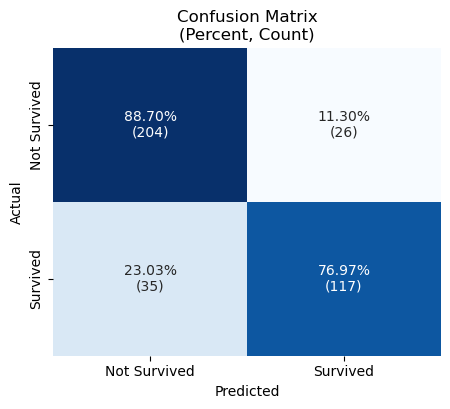


📈 Model Scores:
Log Loss: 0.4268 (Diff from Baseline: 0.0050)
PR AUC: 0.8483 (Diff from Baseline: 0.0026)
F1 Score: 0.8316 (Diff from Baseline: 0.0002)
Precision: 0.8359 (Diff from Baseline: 0.0028)
Recall: 0.8283 (Diff from Baseline: -0.0014)
Accuracy: 0.8403 (Diff from Baseline: -0.0010)


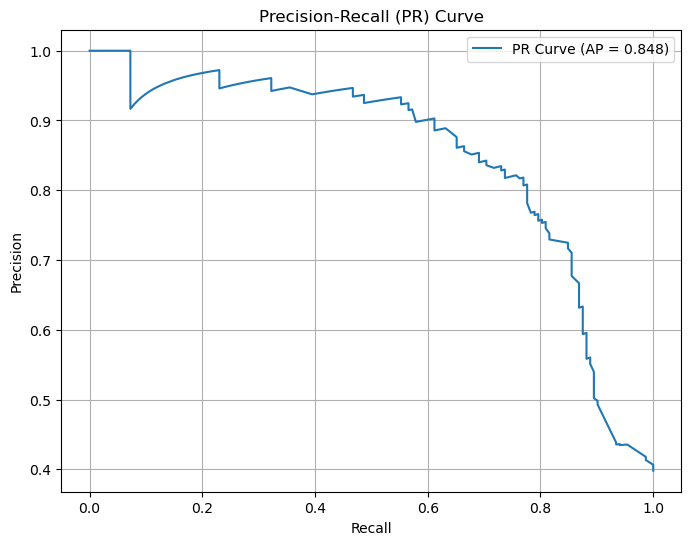

ℹ️ Best threshold for F1 score: 0.341
Max F1 score: 0.793
🏃 View run thundering-trout-462 at: http://ec2-3-136-156-127.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/1fd70ea6e7804a6f83b7ffd61acbe830
🧪 View experiment at: http://ec2-3-136-156-127.us-east-2.compute.amazonaws.com:5000/#/experiments/3

Fold 2/3


[I 2025-06-29 12:45:29,071] A new study created in memory with name: titanic_ml_from_disaster__abridged_fold_2



PREPROCESSING AND TRAINING
Preprocessor will generate 26 features after preprocessing.
✅ No features to drop. Returning input unchanged.

Dedupe flag is set. Checking for duplicates in the training set...
Original Training Set: 475 rows.
⚠️ Found 285 duplicate rows in the training set.
✅ Resolved duplicates: 229 unique rows after deduplication.
Saving clean training set for later use... (229 rows, 26 features)

MODEL EVALUATION

Original Prediction Set: 475 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✅ No features to drop. Returning input unchanged.
Saving clean predicted set for post-analysis... (382 rows)
Model outputted predictions for 382 rows.


[I 2025-06-29 12:45:29,829] Trial 0 finished with value: 0.6931471805599454 and parameters: {'C': 0.0015792576574339525, 'class_weight': 'balanced', 'fit_intercept': False, 'max_iter': 208, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 0 with value: 0.6931471805599454.


Using threshold: 0.341

📈 Model Scores:
Log Loss: 0.6931
PR AUC: 0.3979
F1 Score: 0.2846
Precision: 0.1990
Recall: 0.5000
Accuracy: 0.3979
Preprocessor will generate 26 features after preprocessing.
✅ No features to drop. Returning input unchanged.

Dedupe flag is set. Checking for duplicates in the training set...
Original Training Set: 475 rows.
⚠️ Found 285 duplicate rows in the training set.
✅ Resolved duplicates: 229 unique rows after deduplication.
Saving clean training set for later use... (229 rows, 26 features)

MODEL EVALUATION

Original Prediction Set: 475 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✅ No features to drop. Returning input unchanged.
Saving clean predicted set for post-analysis... (382 rows)
Model outputted predictions for 382 rows.
Using threshold: 0.341


...


📈 Model Scores:
Log Loss: 0.4043
PR AUC: 0.8613
F1 Score: 0.8345
Precision: 0.8383
Recall: 0.8316
Accuracy: 0.8429
Preprocessor will generate 26 features after preprocessing.
✅ No features to drop. Returning input unchanged.

Dedupe flag is set. Checking for duplicates in the training set...
Original Training Set: 475 rows.
⚠️ Found 285 duplicate rows in the training set.
✅ Resolved duplicates: 229 unique rows after deduplication.
Saving clean training set for later use... (229 rows, 26 features)

MODEL EVALUATION

Original Prediction Set: 475 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✅ No features to drop. Returning input unchanged.
Saving clean predicted set for post-analysis... (382 rows)
Model outputted predictions for 382 rows.
Using threshold: 0.341


[I 2025-06-29 12:45:51,318] Trial 28 finished with value: 0.42145953099503597 and parameters: {'C': 0.9630810915696527, 'class_weight': None, 'fit_intercept': True, 'max_iter': 424, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 11 with value: 0.40411876501324817.



📈 Model Scores:
Log Loss: 0.4215
PR AUC: 0.8492
F1 Score: 0.8201
Precision: 0.8194
Recall: 0.8208
Accuracy: 0.8272
Preprocessor will generate 26 features after preprocessing.
✅ No features to drop. Returning input unchanged.

Dedupe flag is set. Checking for duplicates in the training set...
Original Training Set: 475 rows.
⚠️ Found 285 duplicate rows in the training set.
✅ Resolved duplicates: 229 unique rows after deduplication.
Saving clean training set for later use... (229 rows, 26 features)

MODEL EVALUATION

Original Prediction Set: 475 rows.
✅ Deduplicated data: 382 unique rows after deduplication post-processing.
✅ No features to drop. Returning input unchanged.
Saving clean predicted set for post-analysis... (382 rows)
Model outputted predictions for 382 rows.
Using threshold: 0.341


[I 2025-06-29 12:45:52,130] Trial 29 finished with value: 0.6765985840273766 and parameters: {'C': 0.0017617388441896597, 'class_weight': None, 'fit_intercept': False, 'max_iter': 612, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 11 with value: 0.40411876501324817.



📈 Model Scores:
Log Loss: 0.6766
PR AUC: 0.7140
F1 Score: 0.2846
Precision: 0.1990
Recall: 0.5000
Accuracy: 0.3979
Best Trial:
  Value (Log Loss): 0.4041
  Params:
    C: 5.584196313332724
    class_weight: None
    fit_intercept: True
    max_iter: 312
    penalty: l2
    solver: saga

Checking for multicollinearity in the processed training set...
✅ No high correlation pairs found (|r| <= 0.8).

Preprocessor generated the following 27 features:
* Ticket_Frequency_bin_Pair
* Ticket_Frequency_bin_Solo
* Fare_Per_Person_bin_Low
* Fare_Per_Person_bin_Mid
* Pclass_Embarked_1_Q
* Pclass_Embarked_1_S
* Pclass_Embarked_2_C
* Pclass_Embarked_2_Q
* Pclass_Embarked_2_S
* Pclass_Embarked_3_C
* Pclass_Embarked_3_Q
* Pclass_Embarked_3_S
* Age_Bin_Middle_Aged
* Age_Bin_Senior
* Age_Bin_Teen
* Age_Bin_Young_Adult
* Family_Size_Bin_2
* Family_Size_Bin_3-4
* Family_Size_Bin_5+
* Deck_Bin_Rare
* Deck_Bin_Unknown_Deck
* Deck_Bin_Upper
* Pclass_Sex_1_male
* Pclass_Sex_2_female
* Pclass_Sex_2_male
* Pcla

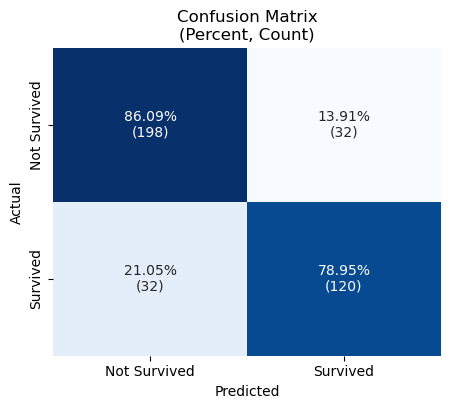


📈 Model Scores:
Log Loss: 0.4207 (Diff from Baseline: -0.0010)
PR AUC: 0.8469 (Diff from Baseline: 0.0013)
F1 Score: 0.8252 (Diff from Baseline: -0.0062)
Precision: 0.8252 (Diff from Baseline: -0.0079)
Recall: 0.8252 (Diff from Baseline: -0.0046)
Accuracy: 0.8325 (Diff from Baseline: -0.0088)


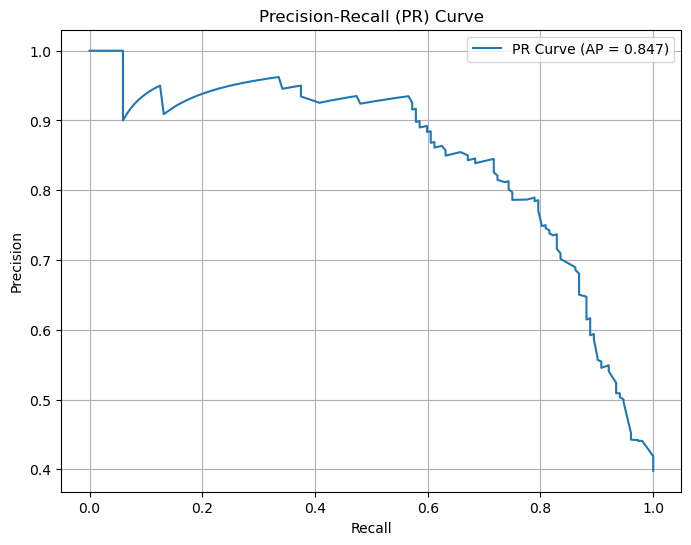

ℹ️ Best threshold for F1 score: 0.320
Max F1 score: 0.791
🏃 View run casual-gnu-392 at: http://ec2-3-136-156-127.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/09385899fdd64a4c97fa0aa984c588d5
🧪 View experiment at: http://ec2-3-136-156-127.us-east-2.compute.amazonaws.com:5000/#/experiments/3

Fold 3/3


[I 2025-06-29 12:45:59,193] A new study created in memory with name: titanic_ml_from_disaster__abridged_fold_3



PREPROCESSING AND TRAINING
Preprocessor will generate 26 features after preprocessing.
✅ No features to drop. Returning input unchanged.

Dedupe flag is set. Checking for duplicates in the training set...
Original Training Set: 475 rows.
⚠️ Found 304 duplicate rows in the training set.
✅ Resolved duplicates: 218 unique rows after deduplication.
Saving clean training set for later use... (218 rows, 26 features)

MODEL EVALUATION

Original Prediction Set: 475 rows.
✅ Deduplicated data: 380 unique rows after deduplication post-processing.
✅ No features to drop. Returning input unchanged.
Saving clean predicted set for post-analysis... (380 rows)
Model outputted predictions for 380 rows.


[I 2025-06-29 12:45:59,940] Trial 0 finished with value: 0.4317568473230479 and parameters: {'C': 26.25262557752965, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 984, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 0 with value: 0.4317568473230479.


Using threshold: 0.341

📈 Model Scores:
Log Loss: 0.4318
PR AUC: 0.8830
F1 Score: 0.8404
Precision: 0.8566
Recall: 0.8329
Accuracy: 0.8500
Preprocessor will generate 26 features after preprocessing.
✅ No features to drop. Returning input unchanged.

Dedupe flag is set. Checking for duplicates in the training set...
Original Training Set: 475 rows.
⚠️ Found 304 duplicate rows in the training set.
✅ Resolved duplicates: 218 unique rows after deduplication.
Saving clean training set for later use... (218 rows, 26 features)

MODEL EVALUATION

Original Prediction Set: 475 rows.
✅ Deduplicated data: 380 unique rows after deduplication post-processing.
✅ No features to drop. Returning input unchanged.
Saving clean predicted set for post-analysis... (380 rows)
Model outputted predictions for 380 rows.
Using threshold: 0.341


...

Using threshold: 0.341

📈 Model Scores:
Log Loss: 0.4142
PR AUC: 0.8687
F1 Score: 0.8229
Precision: 0.8310
Recall: 0.8182
Accuracy: 0.8316
Preprocessor will generate 26 features after preprocessing.
✅ No features to drop. Returning input unchanged.

Dedupe flag is set. Checking for duplicates in the training set...
Original Training Set: 475 rows.
⚠️ Found 304 duplicate rows in the training set.
✅ Resolved duplicates: 218 unique rows after deduplication.
Saving clean training set for later use... (218 rows, 26 features)

MODEL EVALUATION

Original Prediction Set: 475 rows.
✅ Deduplicated data: 380 unique rows after deduplication post-processing.
✅ No features to drop. Returning input unchanged.
Saving clean predicted set for post-analysis... (380 rows)
Model outputted predictions for 380 rows.


[I 2025-06-29 12:46:21,378] Trial 28 finished with value: 0.45343150317782055 and parameters: {'C': 0.22297556243255998, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 559, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 25 with value: 0.41374518518168185.


Using threshold: 0.341

📈 Model Scores:
Log Loss: 0.4534
PR AUC: 0.8570
F1 Score: 0.7968
Precision: 0.7950
Recall: 0.8031
Accuracy: 0.8000
Preprocessor will generate 26 features after preprocessing.
✅ No features to drop. Returning input unchanged.

Dedupe flag is set. Checking for duplicates in the training set...
Original Training Set: 475 rows.
⚠️ Found 304 duplicate rows in the training set.
✅ Resolved duplicates: 218 unique rows after deduplication.
Saving clean training set for later use... (218 rows, 26 features)

MODEL EVALUATION

Original Prediction Set: 475 rows.
✅ Deduplicated data: 380 unique rows after deduplication post-processing.
✅ No features to drop. Returning input unchanged.
Saving clean predicted set for post-analysis... (380 rows)
Model outputted predictions for 380 rows.


[I 2025-06-29 12:46:22,096] Trial 29 finished with value: 0.4120894243979254 and parameters: {'C': 1.946984572969508, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 490, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 29 with value: 0.4120894243979254.


Using threshold: 0.341

📈 Model Scores:
Log Loss: 0.4121
PR AUC: 0.8788
F1 Score: 0.8417
Precision: 0.8525
Recall: 0.8358
Accuracy: 0.8500
Best Trial:
  Value (Log Loss): 0.4121
  Params:
    C: 1.946984572969508
    class_weight: balanced
    fit_intercept: True
    max_iter: 490
    penalty: l1
    solver: liblinear

Checking for multicollinearity in the processed training set...
✅ No high correlation pairs found (|r| <= 0.8).

Preprocessor generated the following 27 features:
* Ticket_Frequency_bin_Pair
* Ticket_Frequency_bin_Solo
* Fare_Per_Person_bin_Low
* Fare_Per_Person_bin_Mid
* Pclass_Embarked_1_Q
* Pclass_Embarked_1_S
* Pclass_Embarked_2_C
* Pclass_Embarked_2_Q
* Pclass_Embarked_2_S
* Pclass_Embarked_3_C
* Pclass_Embarked_3_Q
* Pclass_Embarked_3_S
* Age_Bin_Middle_Aged
* Age_Bin_Senior
* Age_Bin_Teen
* Age_Bin_Young_Adult
* Family_Size_Bin_2
* Family_Size_Bin_3-4
* Family_Size_Bin_5+
* Deck_Bin_Rare
* Deck_Bin_Unknown_Deck
* Deck_Bin_Upper
* Pclass_Sex_1_male
* Pclass_Sex_2_f

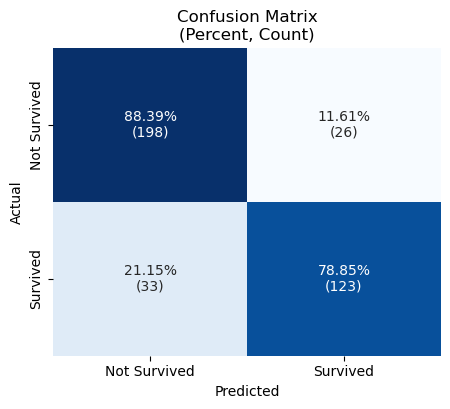


📈 Model Scores:
Log Loss: 0.4120 (Diff from Baseline: -0.0098)
PR AUC: 0.8688 (Diff from Baseline: 0.0231)
F1 Score: 0.8384 (Diff from Baseline: 0.0071)
Precision: 0.8413 (Diff from Baseline: 0.0082)
Recall: 0.8362 (Diff from Baseline: 0.0064)
Accuracy: 0.8447 (Diff from Baseline: 0.0034)


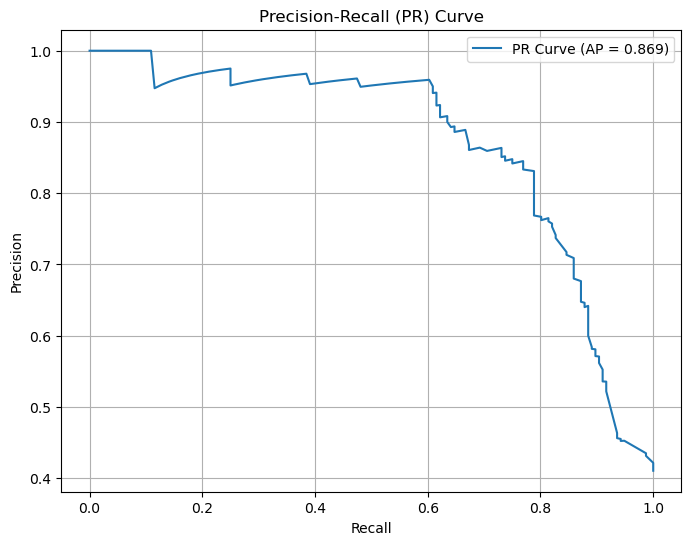

ℹ️ Best threshold for F1 score: 0.350
Max F1 score: 0.809
🏃 View run industrious-kit-456 at: http://ec2-3-136-156-127.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/1b970ea06ce147fca6c946f4f5dc30bc
🧪 View experiment at: http://ec2-3-136-156-127.us-east-2.compute.amazonaws.com:5000/#/experiments/3

CV Results Table (per fold):


,Fold 1,Fold 2,Fold 3
log_loss,0.426755,0.420708,0.411952
pr_auc,0.848297,0.846934,0.868815
f1,0.831578,0.825172,0.838444
precision,0.835869,0.825172,0.841323
recall,0.828347,0.825172,0.836195
accuracy,0.840314,0.832461,0.844737
best_f1_threshold,0.341187,0.320175,0.349655



Best CV Result:
Fold: 3
Log Loss: 0.4120
F1 Threshold: 0.350
Params: {'C': 1.946984572969508, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 490, 'penalty': 'l1', 'solver': 'liblinear'}


In [45]:
mlflow.end_run()
cv_results = []
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X_train[selected_features], y_train)):
    print(f"\nFold {fold + 1}/{outer_cv.n_splits}")
    X_train_fold = X_train[selected_features].iloc[train_idx]
    y_train_fold = y_train.iloc[train_idx]
    X_val_fold = X_train[selected_features].iloc[val_idx]
    y_val_fold = y_train.iloc[val_idx]

    with mlflow.start_run():
        mlflow.set_tag("dataset", "X_train_fold")

        print("\n" + "="*50)
        print("PREPROCESSING AND TRAINING")
        print("="*50)

        preprocessor, optimal_threshold = create_preprocessor(ohe_features)

        def optuna_objective(trial):

            preprocessor.fit(X_train_fold)
            feature_names_after_preprocessing = get_feature_names_from_preprocessor(preprocessor, selected_features)
            feature_names_after_preprocessing = [feat for feat in feature_names_after_preprocessing if feat not in high_corr_features_to_drop_postprocessing]
            print(f"Preprocessor will generate {len(feature_names_after_preprocessing)} features after preprocessing.")
            dropper = FeatureDropper(drop_features=high_corr_features_to_drop_postprocessing)
            dropper.set_input_feature_names(feature_names_after_preprocessing)

            trial_model_params = {
                'C': trial.suggest_float("C", 1e-3, 1e2, log=True), 
                'class_weight': trial.suggest_categorical("class_weight", [None, 'balanced']), 
                'fit_intercept': trial.suggest_categorical("fit_intercept", [True, False]), 
                'max_iter': trial.suggest_int("max_iter", 100, 1000), 
                'penalty': trial.suggest_categorical("penalty", ["l1", "l2"]), 
                'solver': trial.suggest_categorical("solver", ["liblinear", "saga"])
            }

            pipeline = Pipeline([
                ('preprocessor', preprocessor),
                ('dropper', dropper),
                ('classifier', DupFreeClassifier(LogisticRegression(**trial_model_params, random_state=42)))
            ])

            mlflow.log_param("model_type", pipeline.named_steps['classifier'].__class__.__name__)

            pipeline.fit(X_train_fold, y_train_fold)

            scores, _, _, _, _, _ = evaluate_model(pipeline, X_train_fold, y_train_fold, selected_features, threshold=optimal_threshold, skip_visualizations=True)

            return scores['log_loss']  # Use log_loss as the objective to minimize
        
        study = optuna.create_study(direction="minimize", study_name=f"titanic_ml_from_disaster__abridged_fold_{fold + 1}")
        study.optimize(optuna_objective, n_trials=30)
        
        print("Best Trial:")
        print(f"  Value (Log Loss): {study.best_value:.4f}")
        print("  Params:")
        for key, value in study.best_params.items():
            print(f"    {key}: {value}")
        mlflow.log_params(study.best_params)

        # Plot correlation matrix for fitted features to identify potential multicollinearity issues
        # Print feature pairs with high correlation (> 0.8)
        X_train_processed = pipeline.named_steps['classifier'].train_X_clean_
        X_train_processed.columns = feature_names_after_preprocessing
        print("\nChecking for multicollinearity in the processed training set...")
        correlation_matrix = X_train_processed.corr()
        high_corr_pairs = []
        for i in range(len(feature_names_after_preprocessing)):
            for j in range(i + 1, len(feature_names_after_preprocessing)):
                if abs(correlation_matrix.iloc[i, j]) > 0.8:
                    high_corr_pairs.append((feature_names_after_preprocessing[i], feature_names_after_preprocessing[j], correlation_matrix.iloc[i, j]))
        if high_corr_pairs:
            print("⚠️ High Correlation Pairs (|r| > 0.8):")
            for feat1, feat2, corr in high_corr_pairs:
                print(f"* {feat1} and {feat2}: {corr:.2f}") 
        else:
            print("✅ No high correlation pairs found (|r| <= 0.8).") 

        print(f"\nPreprocessor generated the following {len(feature_names_after_preprocessing)} features:")
        for i, feat in enumerate(feature_names_after_preprocessing):
            print(f"* {feat}")
            mlflow.log_param(f"feature_{i}", feat)

        scores, best_f1_threshold, _, _, _, _ = evaluate_model(pipeline, X_train_fold, y_train_fold, selected_features, threshold=optimal_threshold, training_baseline_metrics=baseline_scores)

        cv_results.append({
            'fold': fold + 1,
            'best_f1_threshold': best_f1_threshold,
            'best_trial_params': study.best_params,
            'log_loss': scores['log_loss'],
            'pr_auc': scores['pr_auc'],
            'f1': scores['f1'],
            'precision': scores['precision'],
            'recall': scores['recall'],
            'accuracy': scores['accuracy']
        })

# Convert cv_results to DataFrame for better visualization
cv_results_df = pd.DataFrame(cv_results)
# Only keep relevant columns for display
display_cols = ['log_loss', 'pr_auc', 'f1', 'precision', 'recall', 'accuracy', 'best_f1_threshold']
cv_results_table = cv_results_df[display_cols].T
cv_results_table.columns = [f'Fold {i+1}' for i in range(len(cv_results_table.columns))]
print("\nCV Results Table (per fold):")
display(cv_results_table)

# Print params for CV result with minimal log_loss
best_cv_result = min(cv_results, key=lambda x: x['log_loss'])
print("\nBest CV Result:")
print(f"Fold: {best_cv_result['fold']}")
print(f"Log Loss: {best_cv_result['log_loss']:.4f}")
print(f"F1 Threshold: {best_cv_result['best_f1_threshold']:.3f}")
print(f"Params: {best_cv_result['best_trial_params']}")


#### Stage 3: Final Generalization Evaluation


DEV (HOLDOUT) SET PREDICTION EVALUATION
Refitting model on full training set...
Using best parameters from CV: {'C': 1.946984572969508, 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 490, 'penalty': 'l1', 'solver': 'liblinear'}
✅ No features to drop. Returning input unchanged.

Dedupe flag is set. Checking for duplicates in the training set...
Original Training Set: 891 rows.
⚠️ Found 645 duplicate rows in the training set.
✅ Resolved duplicates: 327 unique rows after deduplication.
Saving clean training set for later use... (327 rows, 27 features)
Evaluating model predictions on holdout set...
Using best F1 threshold from CV: 0.3496554661392351

MODEL EVALUATION

Skipping deduplication and using original data: 179 rows.
✅ No features to drop. Returning input unchanged.
Saving clean predicted set for post-analysis... (179 rows)
Model outputted predictions for 179 rows.
Using threshold: 0.350

Detailed Classification Report:
              precision    recall  f1-score  

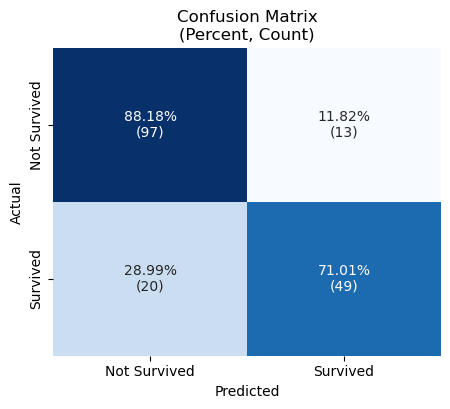


📈 Model Scores:
Log Loss: 0.4542
PR AUC: 0.8001
F1 Score: 0.8014
Precision: 0.8097
Recall: 0.7960
Accuracy: 0.8156


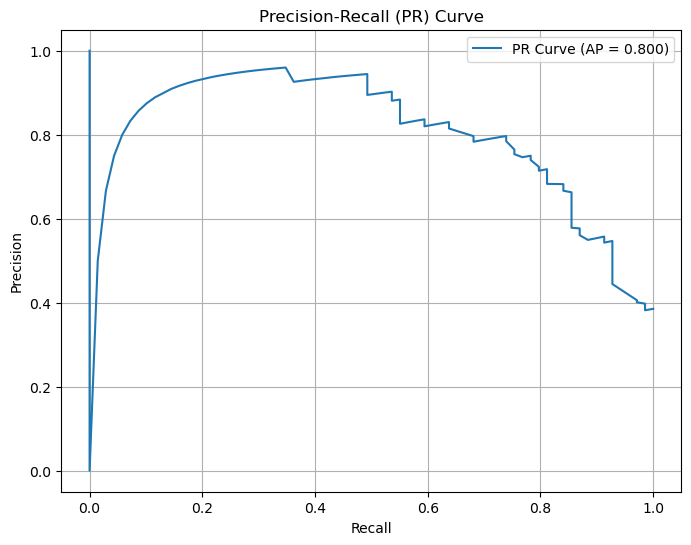

ℹ️ Best threshold for F1 score: 0.329
Max F1 score: 0.767
Logging model to MLflow...


✅ No features to drop. Returning input unchanged.
Saving clean predicted set for post-analysis... (5 rows)


INFO:botocore.credentials:Found credentials in shared credentials file: ~/.aws/credentials
Registered model 'TitanicSurvivalModel' already exists. Creating a new version of this model...
2025/06/29 12:46:40 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: TitanicSurvivalModel, version 12
Created version '12' of model 'TitanicSurvivalModel'.


🏃 View run omniscient-fawn-115 at: http://ec2-3-136-156-127.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/35077301c4d04e33b3f6031d3be8b928
🧪 View experiment at: http://ec2-3-136-156-127.us-east-2.compute.amazonaws.com:5000/#/experiments/3


In [46]:
with mlflow.start_run():
    mlflow.set_tag("dataset", "X_dev")

    print("\n" + "="*50)
    print("DEV (HOLDOUT) SET PREDICTION EVALUATION") 
    print("="*50)

    print("Refitting model on full training set...")
    y_full_train_set = training_set_df['Survived']
    X_full_train_set = training_set_df.drop(columns=['Survived'])
    X_full_train_set = engineer_features(X_full_train_set)

    best_params = best_cv_result['best_trial_params']
    print(f"Using best parameters from CV: {best_params}")
    pipeline.named_steps['classifier'].base_estimator.set_params(**best_params, random_state=42)

    pipeline.fit(X_full_train_set[selected_features], y_full_train_set)

    print("Evaluating model predictions on holdout set...")
    X_dev = engineer_features(X_dev)
    best_f1_threshold = best_cv_result['best_f1_threshold']
    print(f"Using best F1 threshold from CV: {best_f1_threshold}")
    final_generalization_scores, _, _, _, _, _ = evaluate_model(pipeline, X_dev[selected_features], y_dev, selected_features, threshold=best_f1_threshold, deduplicate_X=False, log_model=True)

#### Stages 1-3 Evaluation Summary


Evaluation Summary Table:
                Set  Log Loss    PR AUC  F1 Score  Precision    Recall  \
0   Stg 1: Baseline  0.421741  0.845666  0.831334   0.833111  0.829745   
1  Stg 2: CV Fold 1  0.426755  0.848297  0.831578   0.835869  0.828347   
2  Stg 2: CV Fold 2  0.420708  0.846934  0.825172   0.825172  0.825172   
3  Stg 2: CV Fold 3  0.411952  0.868815  0.838444   0.841323  0.836195   
4    Stg 3: Holdout  0.454225  0.800136  0.801359   0.809691  0.795982   

   Accuracy  
0  0.841292  
1  0.840314  
2  0.832461  
3  0.844737  
4  0.815642  

Model Metric Variance (Baseline - Holdout):
Log Loss Variance: -0.0325
PR AUC Variance: 0.0455
F1 Score Variance: 0.0300
Precision Variance: 0.0234
Recall Variance: 0.0338
Accuracy Variance: 0.0256


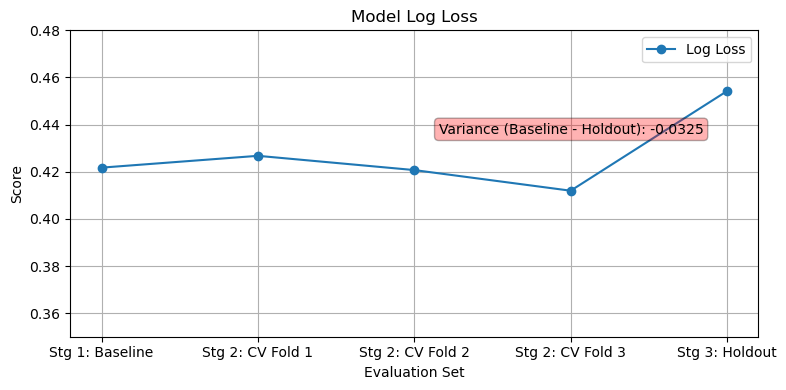

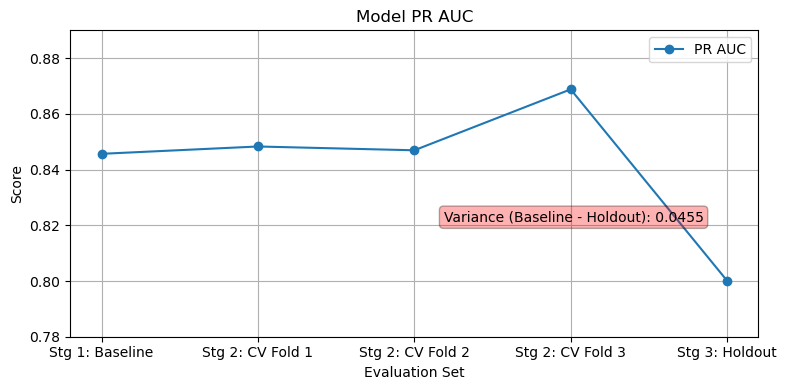

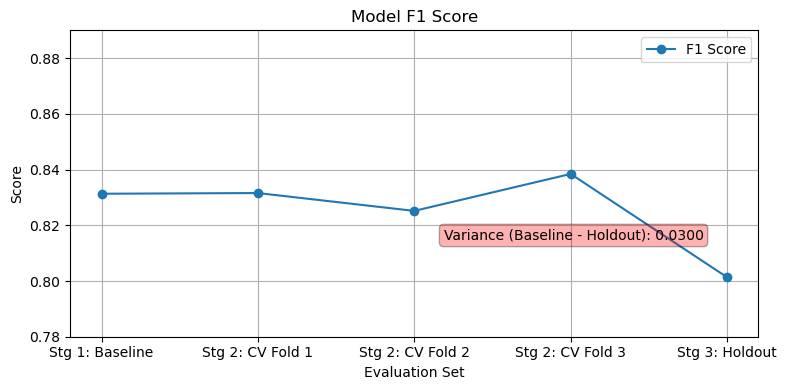

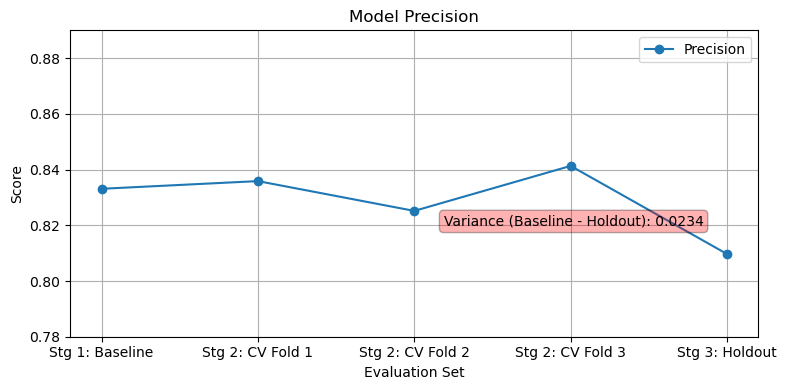

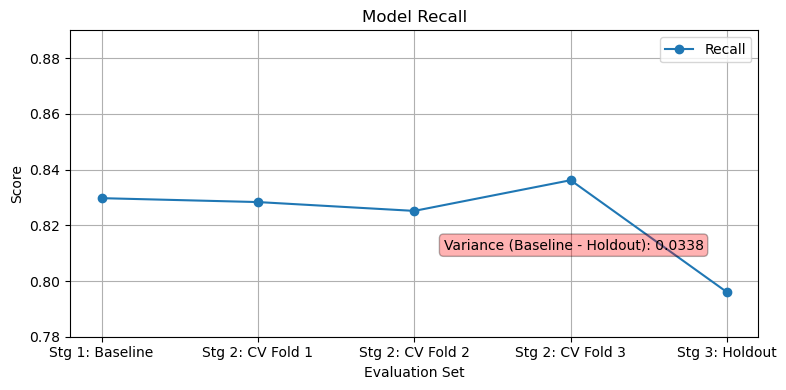

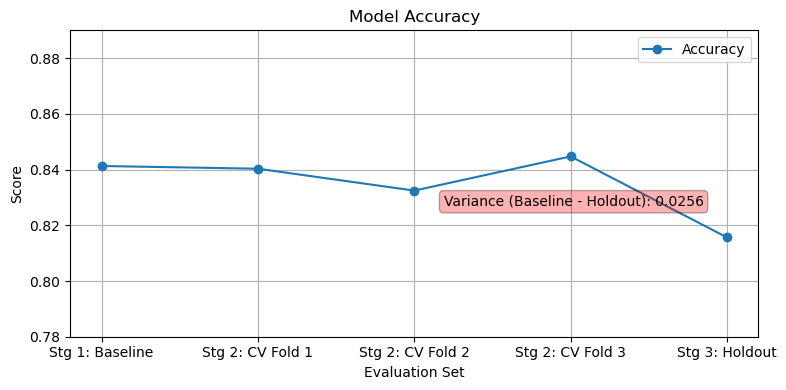

In [47]:
# # Create table summarizing evaluation scores across training, dev, cv, and holdout sets
def create_evaluation_summary_table_and_plot():
    """
    Prints pre- and post-hyperparameter tuning bias/variance,
    returns evaluation summary table, and plots evaluation metrics across all data splits.
    """

    # Create summary table
    # Extract CV metrics from the 'table' DataFrame for each fold
    data = {
        'Set': [
            'Stg 1: Baseline',
            'Stg 2: CV Fold 1',
            'Stg 2: CV Fold 2',
            'Stg 2: CV Fold 3',
            'Stg 3: Holdout'
        ],
        'Log Loss': [
            baseline_scores['log_loss'],
            cv_results_table.loc['log_loss', 'Fold 1'],
            cv_results_table.loc['log_loss', 'Fold 2'],
            cv_results_table.loc['log_loss', 'Fold 3'],
            final_generalization_scores['log_loss']
        ],
        'PR AUC': [
            baseline_scores['pr_auc'],
            cv_results_table.loc['pr_auc', 'Fold 1'],
            cv_results_table.loc['pr_auc', 'Fold 2'],
            cv_results_table.loc['pr_auc', 'Fold 3'],
            final_generalization_scores['pr_auc']
        ],
        'F1 Score': [
            baseline_scores['f1'],
            cv_results_table.loc['f1', 'Fold 1'],
            cv_results_table.loc['f1', 'Fold 2'],
            cv_results_table.loc['f1', 'Fold 3'],
            final_generalization_scores['f1']
        ],
        'Precision': [
            baseline_scores['precision'],
            cv_results_table.loc['precision', 'Fold 1'],
            cv_results_table.loc['precision', 'Fold 2'],
            cv_results_table.loc['precision', 'Fold 3'],
            final_generalization_scores['precision']
        ],
        'Recall': [
            baseline_scores['recall'],
            cv_results_table.loc['recall', 'Fold 1'],
            cv_results_table.loc['recall', 'Fold 2'],
            cv_results_table.loc['recall', 'Fold 3'],
            final_generalization_scores['recall']
        ],
        'Accuracy': [
            baseline_scores['accuracy'],
            cv_results_table.loc['accuracy', 'Fold 1'],
            cv_results_table.loc['accuracy', 'Fold 2'],
            cv_results_table.loc['accuracy', 'Fold 3'],
            final_generalization_scores['accuracy']
        ]
    }
    summary_df = pd.DataFrame(data)

    print("\nEvaluation Summary Table:")
    print(summary_df)

    # Calculate variance between baseline (Stage 1) and holdout (Stage 3) for each metric
    print(f"\nModel Metric Variance (Baseline - Holdout):")
    print(f"Log Loss Variance: {(baseline_scores['log_loss'] - final_generalization_scores['log_loss']):.4f}")
    print(f"PR AUC Variance: {(baseline_scores['pr_auc'] - final_generalization_scores['pr_auc']):.4f}")
    print(f"F1 Score Variance: {(baseline_scores['f1'] - final_generalization_scores['f1']):.4f}")
    print(f"Precision Variance: {(baseline_scores['precision'] - final_generalization_scores['precision']):.4f}")
    print(f"Recall Variance: {(baseline_scores['recall'] - final_generalization_scores['recall']):.4f}")
    print(f"Accuracy Variance: {(baseline_scores['accuracy'] - final_generalization_scores['accuracy']):.4f}")

    for metric in ['Log Loss', 'PR AUC', 'F1 Score', 'Precision', 'Recall', 'Accuracy']:
        plt.figure(figsize=(8, 4))
        plt.plot(summary_df['Set'], summary_df[metric], marker='o', label=metric)
        plt.title(f'Model {metric}')
        plt.ylabel('Score')
        plt.xlabel('Evaluation Set')
        plt.grid(True)
        plt.legend()
        # Set y-axis limits based on metric
        if metric == 'Log Loss':
            plt.ylim(0.35, 0.48)
        else:
            plt.ylim(0.78, 0.89)
        # Calculate variance (Baseline - Holdout)
        baseline_val = summary_df.loc[0, metric]
        holdout_val = summary_df.loc[4, metric]
        variance = baseline_val - holdout_val
        # Annotate variance on the plot
        # Adjust annotation x position to be a bit inside the right edge
        # Set annotation color: red if abs(variance) > 0.02 (2 percentage points), yellow otherwise
        if metric == 'Log Loss':
            # For log loss, use absolute difference threshold (not percentage points)
            color = 'red' if abs(variance) > 0.02 else 'yellow'
        else:
            color = 'red' if abs(variance) > 0.02 else 'yellow'
        plt.annotate(
            f'Variance (Baseline - Holdout): {variance:.4f}',
            xy=(3.85, (baseline_val + holdout_val) / 2),  # 3.85 instead of 4
            xycoords='data',
            ha='right',
            va='center',
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc=color, alpha=0.3)
        )
        plt.tight_layout()
        plt.show()


create_evaluation_summary_table_and_plot()

### Submission File Generation

In [48]:
X_test = engineer_features(X_test)

In [49]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PassengerId         418 non-null    int64  
 1   Pclass              418 non-null    int64  
 2   Name                418 non-null    object 
 3   Sex                 418 non-null    object 
 4   Age                 332 non-null    float64
 5   SibSp               418 non-null    int64  
 6   Parch               418 non-null    int64  
 7   Ticket              418 non-null    object 
 8   Fare                417 non-null    float64
 9   Cabin               91 non-null     object 
 10  Embarked            418 non-null    object 
 11  Deck                418 non-null    object 
 12  Deck_Bin            418 non-null    object 
 13  Title               418 non-null    object 
 14  Family_Size         418 non-null    int64  
 15  Family_Size_Bin     418 non-null    object 
 16  Is_Alone

In [50]:
X_test.isnull().sum().loc[lambda x: x > 0]

Age       86
Fare       1
Cabin    327
dtype: int64

In [51]:
X_test[X_test['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck,Deck_Bin,Title,Family_Size,Family_Size_Bin,Is_Alone,Sex_Pclass_IsAlone,Pclass_Sex
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S,U,Unknown_Deck,Mr,1,1,1,male_3_1,3_male


In [52]:
X_test.isnull().sum().loc[lambda x: x > 0]

Age       86
Fare       1
Cabin    327
dtype: int64

In [53]:
print(f"Predicting on {len(X_test)} rows of test data...")
y_submission_pred_proba = pipeline.predict_proba(X_test[selected_features])[:, 1]
print(f"Model outputted predictions for {len(y_submission_pred_proba)} rows.")
submission = pd.DataFrame({
    'PassengerId': X_test['PassengerId'],
    'Survived': (y_submission_pred_proba >= best_f1_threshold).astype(int)
})
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
filename = f'./submission-{timestamp}.csv'
submission.to_csv(filename, index=False)

Predicting on 418 rows of test data...
✅ No features to drop. Returning input unchanged.
Saving clean predicted set for post-analysis... (418 rows)
Model outputted predictions for 418 rows.


In [54]:
# Confirm no missing values after X_test transformed by pipeline
X_test_predicted = pipeline.named_steps['classifier'].train_X_clean_
X_test_predicted.columns = feature_names_after_preprocessing
X_test_predicted.isnull().sum().loc[lambda x: x > 0]

Series([], dtype: int64)

-----------

In [56]:
import json
import re

def slugify(text):
    text = text.strip()
    text = re.sub(r'[^\w\s\-]', '', text)  # allow (), - and alphanumerics
    return re.sub(r'[\s]+', '-', text)

def extract_headings(ipynb_path):
    with open(ipynb_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    toc_lines = [] # ["## Table of Contents\n"]
    for cell in nb['cells']:
        if cell['cell_type'] == 'markdown':
            for line in cell['source']:
                match = re.match(r'^(#{2,6})\s+(.*)', line)
                if match:
                    level = len(match.group(1)) - 1  # offset for nesting
                    title = match.group(2).strip()
                    anchor = slugify(title)
                    indent = '    ' * (level - 1)
                    toc_lines.append(f"{indent}1. [{title}](#{anchor})")

    return '\n'.join(toc_lines)

# Example usage:
toc = extract_headings("titanic_ml_from_disaster_abridged__paultongyoo.ipynb")
print(toc)

1. [Table of Contents](#Table-of-Contents)
1. [Project Summary](#Project-Summary)
    1. [What I Did](#What-I-Did)
    1. [What I Learned](#What-I-Learned)
    1. [Next Steps](#Next-Steps)
1. [Problem Context](#Problem-Context)
1. [Source Data](#Source-Data)
    1. [Data Dictionary](#Data-Dictionary)
    1. [Variable Notes](#Variable-Notes)
1. [Model Development Strategy](#Model-Development-Strategy)
    1. [Data Sets](#Data-Sets)
    1. [Five Stage Process](#Five-Stage-Process)
    1. [Metrics Strategy](#Metrics-Strategy)
1. [Implementation](#Implementation)
    1. [Descriptive Statistics](#Descriptive-Statistics)
    1. [Data Types](#Data-Types)
    1. [Missing Values Summary](#Missing-Values-Summary)
    1. [Visual Inspection Insights](#Visual-Inspection-Insights)
    1. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
        1. [Survived (Target)](#Survived-Target)
        1. [Age](#Age)
        1. [Fare](#Fare)
        1. [Deck](#Deck)
        1. [Family Size](#Family-Size